# 🩺 SugarMetrics — Diabetes Prediction ML Pipeline
> ** Data Science & Machine Learning**
>
> **Technologies:** Python · Scikit-Learn · Pandas · Matplotlib · Seaborn · Scipy
>
> **Dataset:** Pima Indians Diabetes Dataset (768 records, 9 features)
>
> **Goal:** Build a robust early-stage diabetes prediction system using multiple ML models, feature engineering, hyperparameter tuning, and model explainability.

---

## 📦 1. Imports & Setup

In [1]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings, os, json, joblib

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.3f}'.format)

# ── Scikit-Learn ─────────────────────────────────────────────────────────────
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     GridSearchCV, StratifiedKFold)
from sklearn.preprocessing import (MinMaxScaler, StandardScaler, LabelEncoder,
                                   PolynomialFeatures)
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
from sklearn.feature_selection import SelectKBest, chi2, RFE, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.inspection import permutation_importance
from sklearn.utils import resample

# ── Plot Style ───────────────────────────────────────────────────────────────
PALETTE = ['#2ECC71','#E74C3C']
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi':100,'font.family':'DejaVu Sans','font.size':11})

print("✅  All libraries loaded successfully!")
print(f"NumPy: {np.__version__} | Pandas: {pd.__version__}")

✅  All libraries loaded successfully!
NumPy: 2.3.5 | Pandas: 2.3.3


---
## 📊 WEEK 1, DAY 1 — Exploratory Data Analysis (EDA)

### Task-1: Load Dataset & Preview

In [2]:
df = pd.read_csv('Pima_diabetes.csv')
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns\n")
print("── First 5 Rows ──")
df.head()

Dataset Shape: 768 rows × 9 columns

── First 5 Rows ──


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.600,0.627,50,1
1,1,85,66,29,0,26.600,0.351,31,0
2,8,183,64,0,0,23.300,0.672,32,1
3,1,89,66,23,94,28.100,0.167,21,0
4,0,137,40,35,168,43.100,2.288,33,1


### Task-2: Check Missing Values

In [3]:
print("── Missing / NaN Values Per Column ──")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)
print(f"\nTotal missing cells: {df.isnull().sum().sum()}")

── Missing / NaN Values Per Column ──
                          Missing Count  Missing %
Pregnancies                           0      0.000
Glucose                               0      0.000
BloodPressure                         0      0.000
SkinThickness                         0      0.000
Insulin                               0      0.000
BMI                                   0      0.000
DiabetesPedigreeFunction              0      0.000
Age                                   0      0.000
Outcome                               0      0.000

Total missing cells: 0


### Task-3: Summary Statistics

In [4]:
print("── Descriptive Statistics ──")
df.describe().round(2)

── Descriptive Statistics ──


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000,768.000,768.000,768.000,768.000,768.000,768.000,768.000,768.000
mean,3.850,120.890,69.110,20.540,79.800,31.990,0.470,33.240,0.350
std,3.370,31.970,19.360,15.950,115.240,7.880,0.330,11.760,0.480
min,0.000,0.000,0.000,0.000,0.000,0.000,0.080,21.000,0.000
25%,1.000,99.000,62.000,0.000,0.000,27.300,0.240,24.000,0.000
50%,3.000,117.000,72.000,23.000,30.500,32.000,0.370,29.000,0.000
75%,6.000,140.250,80.000,32.000,127.250,36.600,0.630,41.000,1.000
max,17.000,199.000,122.000,99.000,846.000,67.100,2.420,81.000,1.000


### Task-4: Data Types & Unique Values

In [5]:
dtypes_df = pd.DataFrame({
    'dtype': df.dtypes,
    'unique_values': df.nunique(),
    'sample': [df[c].unique()[:4] for c in df.columns]
})
print(dtypes_df)

                            dtype  unique_values                        sample
Pregnancies                 int64             17                  [6, 1, 8, 0]
Glucose                     int64            136            [148, 85, 183, 89]
BloodPressure               int64             47              [72, 66, 64, 40]
SkinThickness               int64             51               [35, 29, 0, 23]
Insulin                     int64            186              [0, 94, 168, 88]
BMI                       float64            248      [33.6, 26.6, 23.3, 28.1]
DiabetesPedigreeFunction  float64            517  [0.627, 0.351, 0.672, 0.167]
Age                         int64             52              [50, 31, 32, 21]
Outcome                     int64              2                        [1, 0]


### Task-5: Target Variable Distribution

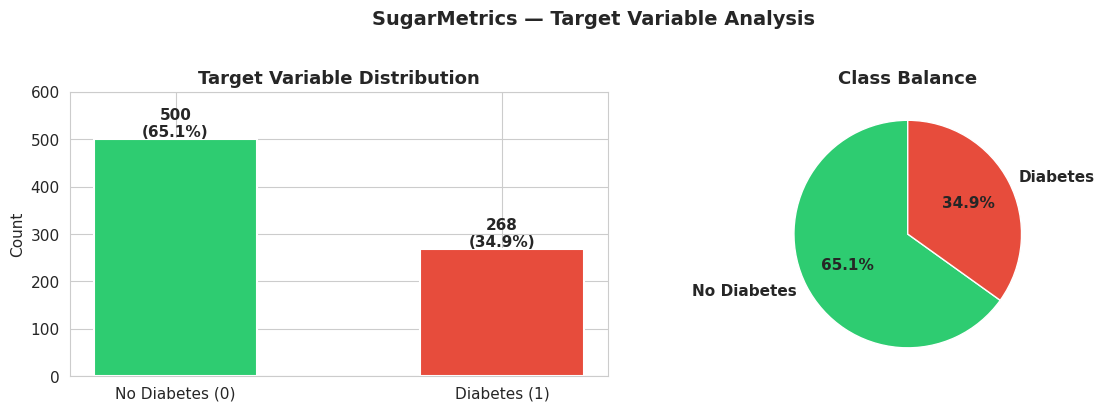


Class Ratio (Non-Diabetic:Diabetic) = 500:268 (1.87:1)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count Plot
vc = df['Outcome'].value_counts()
bars = axes[0].bar(['No Diabetes (0)', 'Diabetes (1)'], vc.values,
                    color=PALETTE, width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, vc.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_title('Target Variable Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, vc.max()*1.2)

# Pie chart
axes[1].pie(vc.values, labels=['No Diabetes', 'Diabetes'],
            colors=PALETTE, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize':11,'fontweight':'bold'})
axes[1].set_title('Class Balance', fontsize=13, fontweight='bold')

plt.suptitle('SugarMetrics — Target Variable Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('target_distribution.png', bbox_inches='tight', dpi=120)
plt.show()
print(f"\nClass Ratio (Non-Diabetic:Diabetic) = {vc[0]}:{vc[1]} ({vc[0]/vc[1]:.2f}:1)")

---
## 📈 WEEK 1, DAY 2 — Data Visualization (Part 1)

### Task-1: Feature Distributions (Histograms)

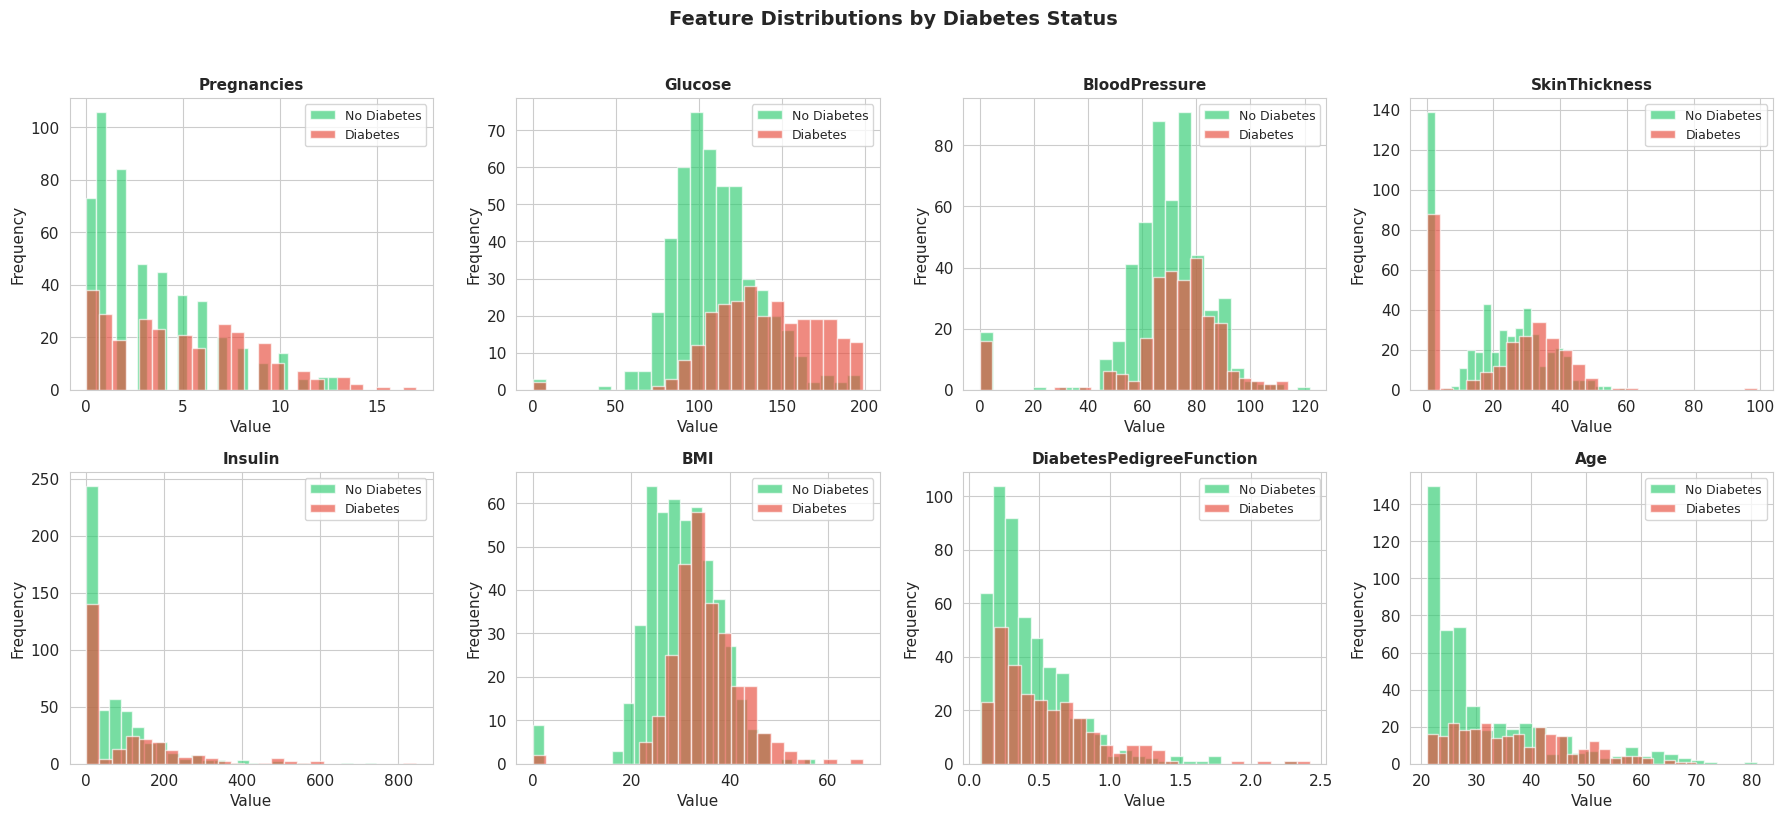

In [7]:
features = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
           'Insulin','BMI','DiabetesPedigreeFunction','Age']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].hist(df[df['Outcome']==0][feat], bins=25, alpha=0.65, color=PALETTE[0],
                 label='No Diabetes', edgecolor='white')
    axes[i].hist(df[df['Outcome']==1][feat], bins=25, alpha=0.65, color=PALETTE[1],
                 label='Diabetes', edgecolor='white')
    axes[i].set_title(feat, fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Value'); axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=9)

plt.suptitle('Feature Distributions by Diabetes Status', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions.png', bbox_inches='tight', dpi=120)
plt.show()

### Task-2: Outlier Detection — Boxplots

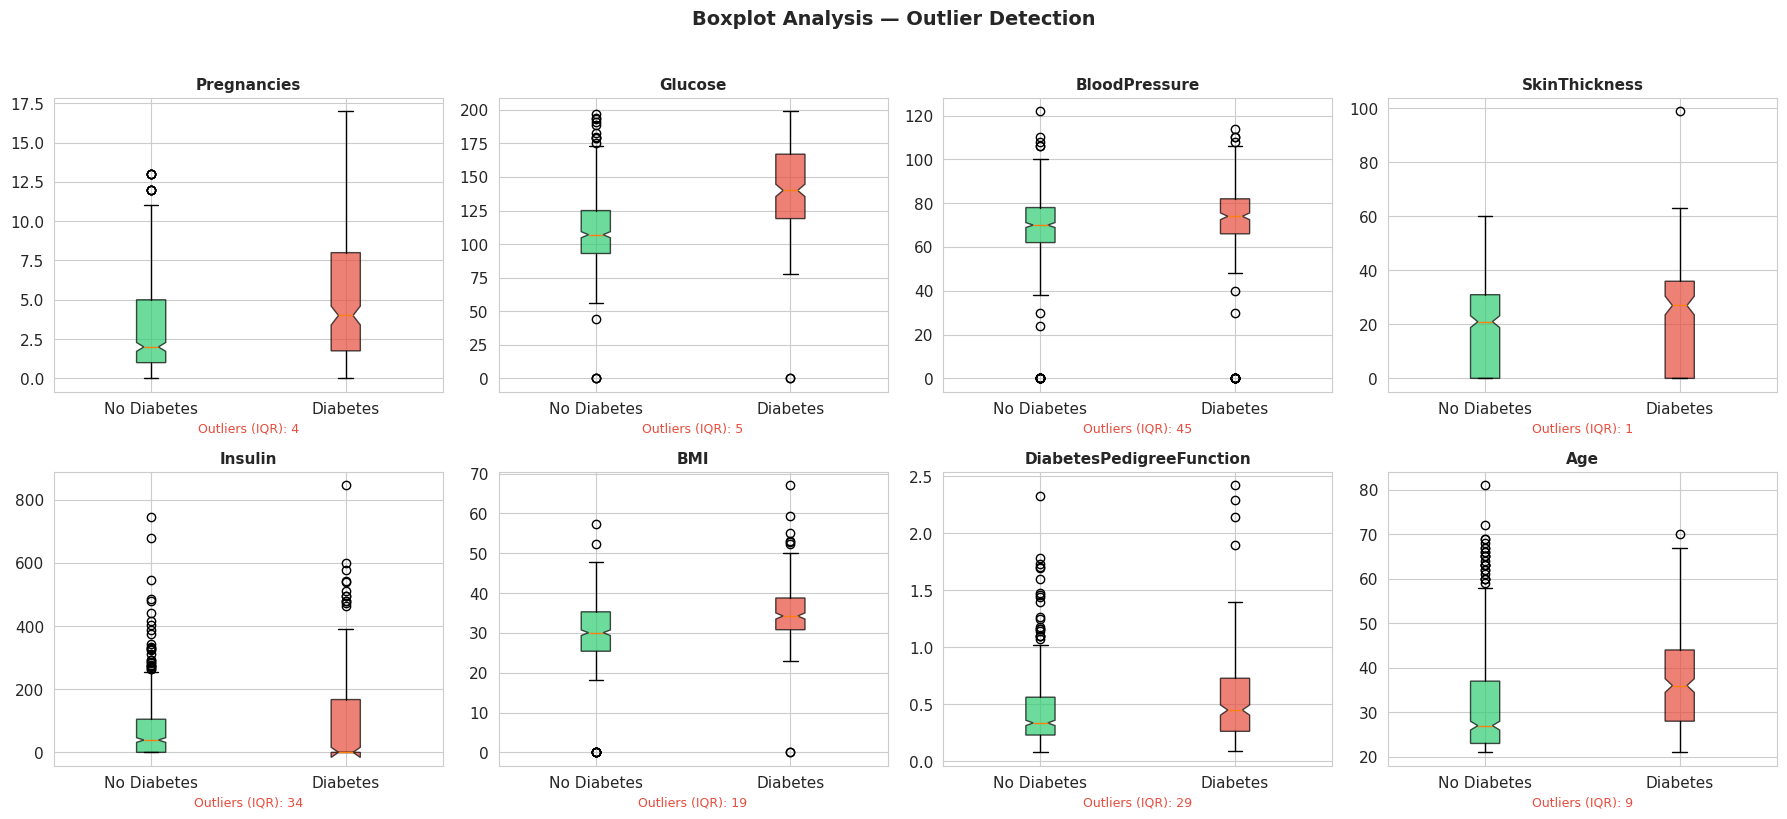

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    bp_data = [df[df['Outcome']==0][feat], df[df['Outcome']==1][feat]]
    bp_plot = axes[i].boxplot(bp_data, labels=['No Diabetes','Diabetes'],
                               patch_artist=True, notch=True)
    for patch, color in zip(bp_plot['boxes'], PALETTE):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    axes[i].set_title(feat, fontweight='bold', fontsize=11)
    # IQR outlier count
    Q1,Q3 = df[feat].quantile([0.25,0.75])
    IQR=Q3-Q1
    outliers=((df[feat]<Q1-1.5*IQR)|(df[feat]>Q3+1.5*IQR)).sum()
    axes[i].set_xlabel(f'Outliers (IQR): {outliers}', fontsize=9, color='#e74c3c')

plt.suptitle('Boxplot Analysis — Outlier Detection', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('boxplots_outliers.png', bbox_inches='tight', dpi=120)
plt.show()

### Task-3: Correlation Heatmap

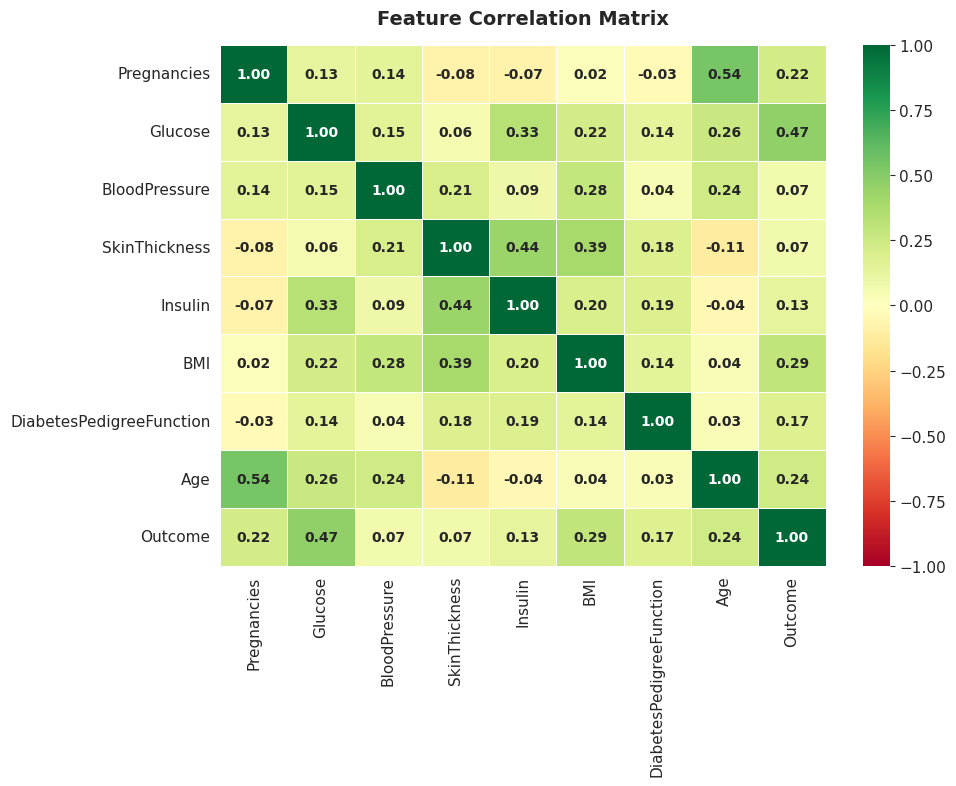


Top Features Correlated with Outcome:
Glucose                    0.467
BMI                        0.293
Age                        0.238
Pregnancies                0.222
DiabetesPedigreeFunction   0.174
Insulin                    0.131
SkinThickness              0.075
BloodPressure              0.065


In [9]:
corr = df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, linecolor='white',
            annot_kws={'fontsize':10,'fontweight':'bold'})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=120)
plt.show()

# Top correlations with Outcome
corr_outcome = corr['Outcome'].drop('Outcome').sort_values(ascending=False)
print("\nTop Features Correlated with Outcome:")
print(corr_outcome.to_string())

### Task-4: Scatter Plots — Feature Pairs

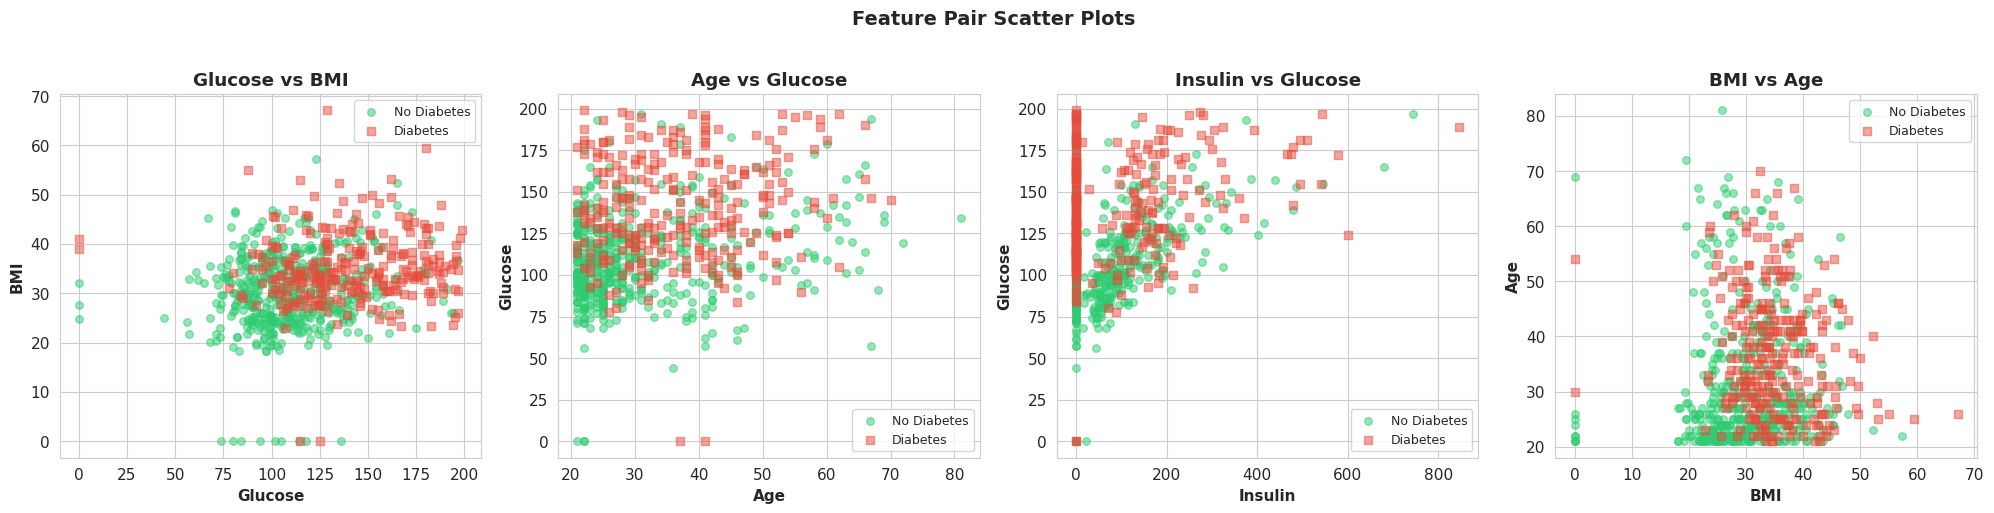

In [10]:
pairs = [('Glucose','BMI'),('Age','Glucose'),('Insulin','Glucose'),('BMI','Age')]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (x,y) in zip(axes, pairs):
    for label, color, marker in zip([0,1], PALETTE, ['o','s']):
        subset = df[df['Outcome']==label]
        ax.scatter(subset[x], subset[y], c=color, alpha=0.5, s=30,
                   marker=marker, label=['No Diabetes','Diabetes'][label])
    ax.set_xlabel(x, fontweight='bold'); ax.set_ylabel(y, fontweight='bold')
    ax.set_title(f'{x} vs {y}', fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Feature Pair Scatter Plots', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('scatter_pairs.png', bbox_inches='tight', dpi=120)
plt.show()

### Task-5: Glucose Distribution by Class

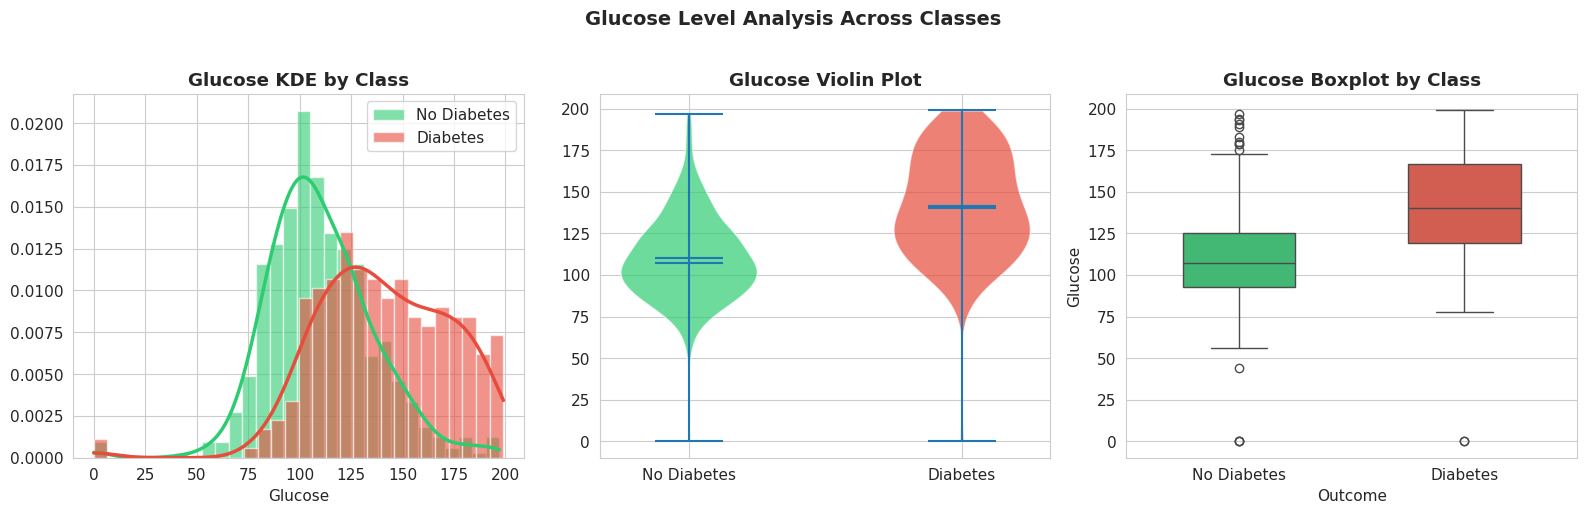

T-test: t=-14.60, p=8.94e-43 — Significant


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# KDE Plot
for label, color in zip([0,1], PALETTE):
    subset = df[df['Outcome']==label]['Glucose']
    axes[0].hist(subset, bins=30, alpha=0.6, color=color, density=True,
                 label=['No Diabetes','Diabetes'][label])
    from scipy.stats import gaussian_kde
    kde_x = np.linspace(subset.min(), subset.max(), 200)
    kde = gaussian_kde(subset)
    axes[0].plot(kde_x, kde(kde_x), color=color, linewidth=2.5)
axes[0].set_title('Glucose KDE by Class', fontweight='bold')
axes[0].set_xlabel('Glucose'); axes[0].legend()

# Violin
violin_data = [df[df['Outcome']==0]['Glucose'].values, df[df['Outcome']==1]['Glucose'].values]
vp = axes[1].violinplot(violin_data, positions=[0,1], showmedians=True, showmeans=True)
for pc, color in zip(vp['bodies'], PALETTE):
    pc.set_facecolor(color); pc.set_alpha(0.7)
axes[1].set_xticks([0,1]); axes[1].set_xticklabels(['No Diabetes','Diabetes'])
axes[1].set_title('Glucose Violin Plot', fontweight='bold')

# Box + Swarm
sns.boxplot(x='Outcome', y='Glucose', data=df, palette=PALETTE, ax=axes[2], width=0.5)
axes[2].set_title('Glucose Boxplot by Class', fontweight='bold')
axes[2].set_xticklabels(['No Diabetes','Diabetes'])

plt.suptitle('Glucose Level Analysis Across Classes', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('glucose_analysis.png', bbox_inches='tight', dpi=120)
plt.show()

# Statistical test
g0 = df[df['Outcome']==0]['Glucose']
g1 = df[df['Outcome']==1]['Glucose']
t_stat, p_val = stats.ttest_ind(g0, g1)
print(f"T-test: t={t_stat:.2f}, p={p_val:.2e} — {'Significant' if p_val<0.05 else 'Not Significant'}")

---
## 📉 WEEK 1, DAY 3 — Data Visualization (Part 2)

### Task-1: BMI Distribution by Class

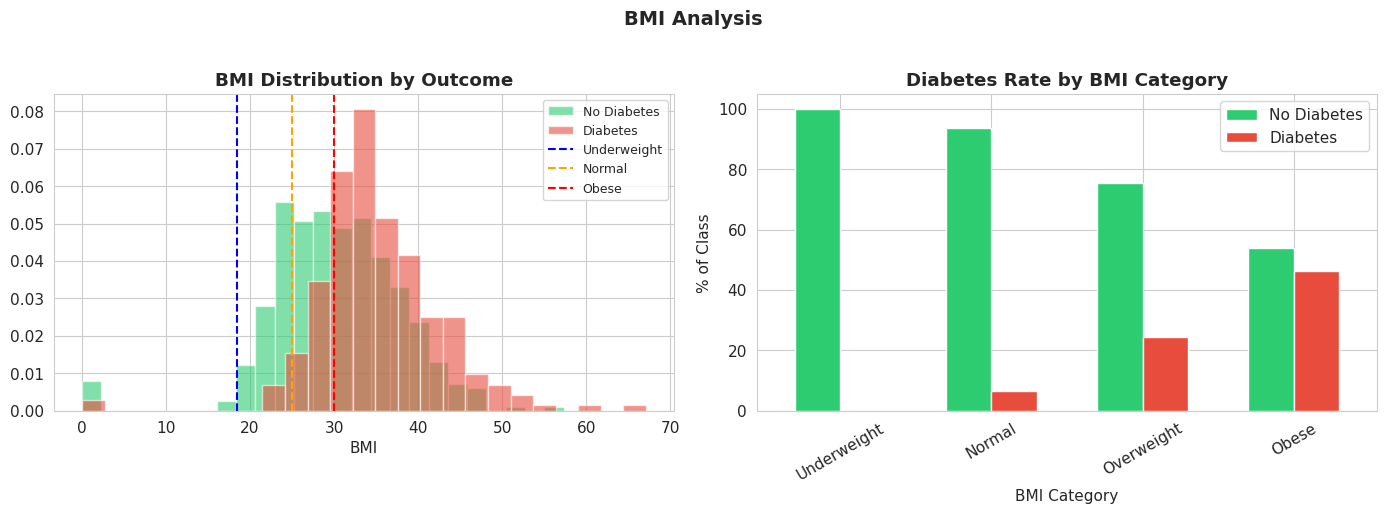

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BMI Histogram
for label, color in zip([0,1], PALETTE):
    axes[0].hist(df[df['Outcome']==label]['BMI'], bins=25, alpha=0.6, color=color,
                 label=['No Diabetes','Diabetes'][label], density=True)
axes[0].axvline(18.5, color='blue', ls='--', lw=1.5, label='Underweight')
axes[0].axvline(25, color='orange', ls='--', lw=1.5, label='Normal')
axes[0].axvline(30, color='red', ls='--', lw=1.5, label='Obese')
axes[0].set_title('BMI Distribution by Outcome', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].set_xlabel('BMI')

# BMI Category Counts
df['BMI_Cat'] = pd.cut(df['BMI'],bins=[0,18.5,25,30,100],
                        labels=['Underweight','Normal','Overweight','Obese'])
bmi_cross = pd.crosstab(df['BMI_Cat'], df['Outcome'], normalize='index')*100
bmi_cross.plot(kind='bar', ax=axes[1], color=PALETTE, width=0.6, edgecolor='white')
axes[1].set_title('Diabetes Rate by BMI Category', fontweight='bold')
axes[1].set_xlabel('BMI Category'); axes[1].set_ylabel('% of Class')
axes[1].legend(['No Diabetes','Diabetes']); axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('BMI Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('bmi_analysis.png', bbox_inches='tight', dpi=120); plt.show()

### Task-2: Age vs Diabetes Risk

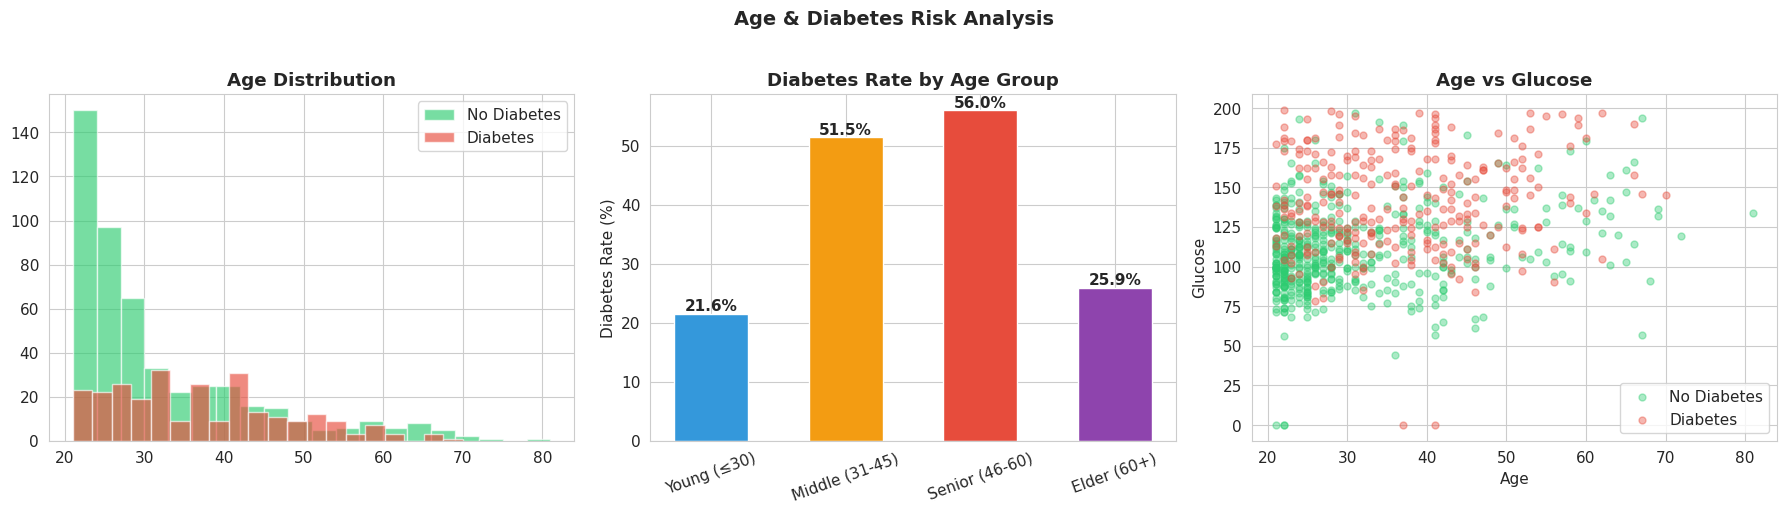

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age Distribution
for label, color in zip([0,1], PALETTE):
    axes[0].hist(df[df['Outcome']==label]['Age'], bins=20, alpha=0.65, color=color,
                 label=['No Diabetes','Diabetes'][label])
axes[0].set_title('Age Distribution', fontweight='bold'); axes[0].legend()

# Age bins
df['Age_Group'] = pd.cut(df['Age'], bins=[0,30,45,60,100],
                          labels=['Young (≤30)','Middle (31-45)','Senior (46-60)','Elder (60+)'])
age_rate = df.groupby('Age_Group')['Outcome'].mean()*100
colors_age = ['#3498db','#f39c12','#e74c3c','#8e44ad']
bars = axes[1].bar(age_rate.index, age_rate.values, color=colors_age, width=0.55, edgecolor='white')
for bar, val in zip(bars, age_rate.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Diabetes Rate by Age Group', fontweight='bold')
axes[1].set_ylabel('Diabetes Rate (%)'); axes[1].tick_params(axis='x', rotation=20)

# Age scatter vs Glucose
for label, color in zip([0,1], PALETTE):
    s = df[df['Outcome']==label]
    axes[2].scatter(s['Age'], s['Glucose'], c=color, alpha=0.4, s=25,
                    label=['No Diabetes','Diabetes'][label])
axes[2].set_xlabel('Age'); axes[2].set_ylabel('Glucose')
axes[2].set_title('Age vs Glucose', fontweight='bold'); axes[2].legend()

plt.suptitle('Age & Diabetes Risk Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('age_analysis.png', bbox_inches='tight', dpi=120); plt.show()

### Task-3: Pregnancies vs Diabetes

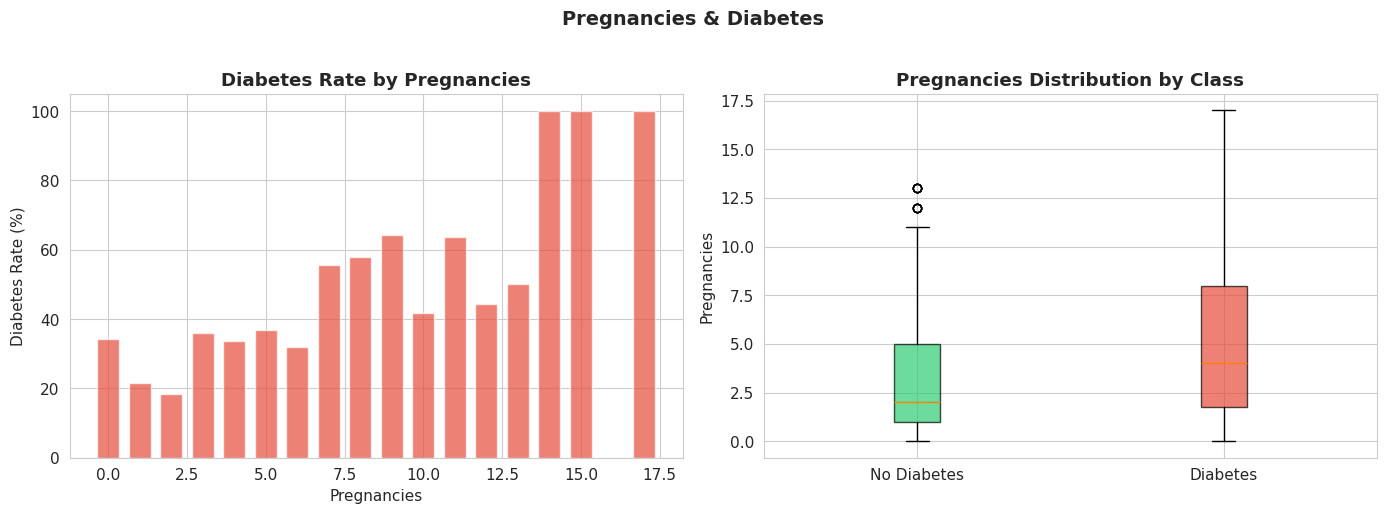

T-test Pregnancies: t=-6.30, p=0.0000


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pregnancies by Outcome
preg_rate = df.groupby('Pregnancies')['Outcome'].agg(['mean','count'])
axes[0].bar(preg_rate.index, preg_rate['mean']*100, color='#e74c3c', alpha=0.7, width=0.7)
axes[0].set_title('Diabetes Rate by Pregnancies', fontweight='bold')
axes[0].set_xlabel('Pregnancies'); axes[0].set_ylabel('Diabetes Rate (%)')

# Box comparison
bp_data = [df[df['Outcome']==0]['Pregnancies'], df[df['Outcome']==1]['Pregnancies']]
bx = axes[1].boxplot(bp_data, labels=['No Diabetes','Diabetes'], patch_artist=True, notch=False)
for patch, color in zip(bx['boxes'], PALETTE): patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1].set_title('Pregnancies Distribution by Class', fontweight='bold')
axes[1].set_ylabel('Pregnancies')

plt.suptitle('Pregnancies & Diabetes', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('pregnancies_analysis.png', bbox_inches='tight', dpi=120); plt.show()

t_stat, p_val = stats.ttest_ind(df[df['Outcome']==0]['Pregnancies'],df[df['Outcome']==1]['Pregnancies'])
print(f"T-test Pregnancies: t={t_stat:.2f}, p={p_val:.4f}")

### Task-4: Feature Correlation with Target

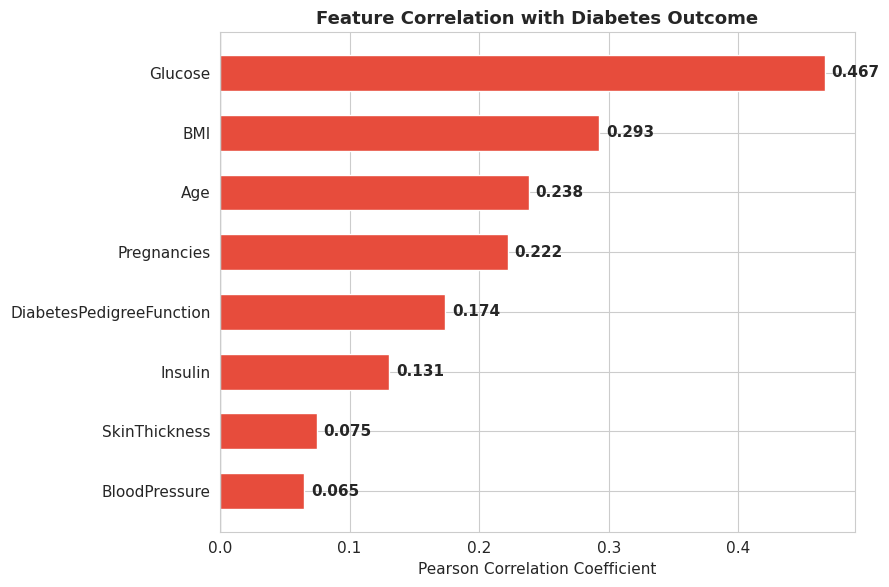

In [15]:
corr_with_target = df.select_dtypes(include='number').corr()['Outcome'].drop('Outcome').sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9,6))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_with_target.values]
bars = ax.barh(corr_with_target.index, corr_with_target.values, color=colors,
               height=0.6, edgecolor='white')
for bar, val in zip(bars, corr_with_target.values):
    ax.text(val + (0.005 if val >= 0 else -0.005), bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val>=0 else 'right', fontweight='bold')
ax.axvline(0, color='black', linewidth=1.5)
ax.set_title('Feature Correlation with Diabetes Outcome', fontsize=13, fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
plt.tight_layout(); 
plt.savefig('correlation_target.png', bbox_inches='tight', dpi=120); 
plt.show()

### Task-5: Key EDA Summary Findings

In [16]:
print("=" * 60)
print("  SUGARMETRICS — EDA KEY FINDINGS SUMMARY")
print("=" * 60)
print(f"  Dataset: {df.shape[0]} samples, {df.shape[1]-1} features + 1 target")
print(f"  Diabetic: {df['Outcome'].sum()} ({df['Outcome'].mean()*100:.1f}%)")
print(f"  Non-Diabetic: {(df['Outcome']==0).sum()} ({(df['Outcome']==0).mean()*100:.1f}%)")
print()
print("  TOP RISK FACTORS (by correlation):")
for feat, val in corr_with_target.sort_values(ascending=False).items():
    print(f"    {feat:<28} r = {val:+.3f}")
print()
print("  NOTABLE OBSERVATIONS:")
print(f"  • Avg Glucose (Diabetic)    : {df[df['Outcome']==1]['Glucose'].mean():.1f}")
print(f"  • Avg Glucose (Non-Diabetic): {df[df['Outcome']==0]['Glucose'].mean():.1f}")
print(f"  • Avg BMI (Diabetic)        : {df[df['Outcome']==1]['BMI'].mean():.1f}")
print(f"  • Avg Age (Diabetic)        : {df[df['Outcome']==1]['Age'].mean():.1f}")
print("=" * 60)

  SUGARMETRICS — EDA KEY FINDINGS SUMMARY
  Dataset: 768 samples, 10 features + 1 target
  Diabetic: 268 (34.9%)
  Non-Diabetic: 500 (65.1%)

  TOP RISK FACTORS (by correlation):
    Glucose                      r = +0.467
    BMI                          r = +0.293
    Age                          r = +0.238
    Pregnancies                  r = +0.222
    DiabetesPedigreeFunction     r = +0.174
    Insulin                      r = +0.131
    SkinThickness                r = +0.075
    BloodPressure                r = +0.065

  NOTABLE OBSERVATIONS:
  • Avg Glucose (Diabetic)    : 141.3
  • Avg Glucose (Non-Diabetic): 110.0
  • Avg BMI (Diabetic)        : 35.1
  • Avg Age (Diabetic)        : 37.1


---
## 🔧 WEEK 1, DAY 4 — Feature Engineering (Part 1)

### Task-1: Handle Missing Values (Zero-Values)

In [17]:
df_clean = df.copy()

# Columns where 0 is physiologically impossible → treat as missing
zero_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in zero_cols:
    zeros = (df_clean[col] == 0).sum()
    if zeros > 0:
        median_val = df_clean[df_clean[col] > 0][col].median()
        df_clean[col] = df_clean[col].replace(0, median_val)
        print(f"  {col}: replaced {zeros} zeros with median {median_val:.1f}")
    else:
        print(f"  {col}: no zeros found")

print(f"\nAfter cleaning — missing values: {df_clean.isnull().sum().sum()}")

  Glucose: replaced 5 zeros with median 117.0
  BloodPressure: replaced 35 zeros with median 72.0
  SkinThickness: replaced 227 zeros with median 29.0
  Insulin: replaced 374 zeros with median 125.0
  BMI: replaced 11 zeros with median 32.3

After cleaning — missing values: 11


### Task-2: Label Encoding & Categorical Encoding

In [18]:
# Label Encoding BMI categories (created in Day 3)
le = LabelEncoder()
df_clean['BMI_Cat_Enc'] = le.fit_transform(df_clean['BMI_Cat'].astype(str))
df_clean['Age_Group_Enc'] = le.fit_transform(df_clean['Age_Group'].astype(str))

print("Label Encoded BMI Categories:")
print(dict(zip(le.classes_, le.transform(le.classes_))))
print("\nSample rows:")
df_clean[['BMI','BMI_Cat','BMI_Cat_Enc','Age','Age_Group','Age_Group_Enc']].head(6)

Label Encoded BMI Categories:
{'Elder (60+)': np.int64(0), 'Middle (31-45)': np.int64(1), 'Senior (46-60)': np.int64(2), 'Young (≤30)': np.int64(3)}

Sample rows:


,BMI,BMI_Cat,BMI_Cat_Enc,Age,Age_Group,Age_Group_Enc
0,33.600,Obese,1,50,Senior (46-60),2
1,26.600,Overweight,2,31,Middle (31-45),1
2,23.300,Normal,0,32,Middle (31-45),1
3,28.100,Overweight,2,21,Young (≤30),3
4,43.100,Obese,1,33,Middle (31-45),1
5,25.600,Overweight,2,30,Young (≤30),3


### Task-3: MinMax Normalization [0,1]

In [19]:
num_features = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
               'Insulin','BMI','DiabetesPedigreeFunction','Age']

scaler_minmax = MinMaxScaler()
df_normalized = df_clean[num_features].copy()
df_normalized[num_features] = scaler_minmax.fit_transform(df_normalized[num_features])

print("MinMax Scaled feature ranges:")
for col in num_features:
    print(f"  {col:<28}: [{df_normalized[col].min():.3f}, {df_normalized[col].max():.3f}]")

MinMax Scaled feature ranges:
  Pregnancies                 : [0.000, 1.000]
  Glucose                     : [0.000, 1.000]
  BloodPressure               : [0.000, 1.000]
  SkinThickness               : [0.000, 1.000]
  Insulin                     : [0.000, 1.000]
  BMI                         : [0.000, 1.000]
  DiabetesPedigreeFunction    : [0.000, 1.000]
  Age                         : [0.000, 1.000]


### Task-4: IQR Outlier Detection & Treatment

In [20]:
df_no_outliers = df_clean.copy()
outlier_report = {}
for col in ['Glucose','Insulin','BMI','DiabetesPedigreeFunction']:
    Q1, Q3 = df_no_outliers[col].quantile(0.25), df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers_mask = (df_no_outliers[col] < lower) | (df_no_outliers[col] > upper)
    count = outliers_mask.sum()
    # Winsorize (cap at bounds)
    df_no_outliers[col] = df_no_outliers[col].clip(lower, upper)
    outlier_report[col] = {'count': int(count), 'lower': round(lower,2), 'upper': round(upper,2)}
    print(f"  {col:<30}: {count} outliers capped [{lower:.1f}, {upper:.1f}]")

print(f"\nShape after outlier treatment: {df_no_outliers.shape}")

  Glucose                       : 0 outliers capped [39.0, 201.0]
  Insulin                       : 346 outliers capped [112.9, 135.9]
  BMI                           : 8 outliers capped [13.8, 50.2]
  DiabetesPedigreeFunction      : 29 outliers capped [-0.3, 1.2]

Shape after outlier treatment: (768, 13)


### Task-5: Remove Duplicates

In [21]:
dups = df_no_outliers.duplicated().sum()
print(f"Duplicate rows found: {dups}")
df_no_outliers = df_no_outliers.drop_duplicates().reset_index(drop=True)
print(f"Shape after deduplication: {df_no_outliers.shape}")

Duplicate rows found: 0
Shape after deduplication: (768, 13)


---
## 🔧 WEEK 1, DAY 5 — Feature Engineering (Part 2)

### Task-1: Log Transformation for Skewed Features

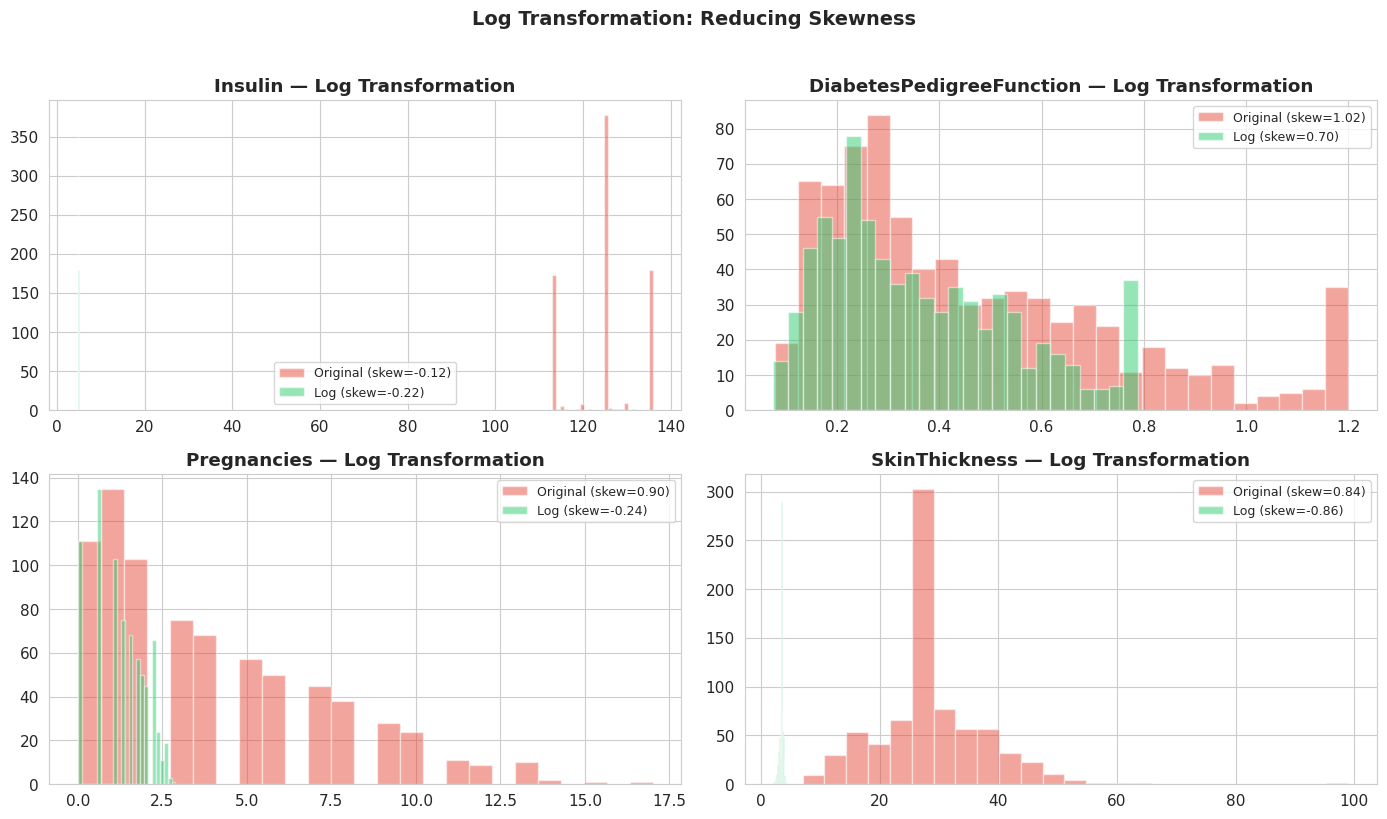

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(14,8))
skewed_cols = ['Insulin','DiabetesPedigreeFunction','Pregnancies','SkinThickness']

for ax, col in zip(axes.flatten(), skewed_cols):
    before_skew = df_no_outliers[col].skew()
    df_no_outliers[f'{col}_Log'] = np.log1p(df_no_outliers[col])
    after_skew = df_no_outliers[f'{col}_Log'].skew()
    ax.hist(df_no_outliers[col], bins=25, alpha=0.5, color='#e74c3c', label=f'Original (skew={before_skew:.2f})')
    ax.hist(df_no_outliers[f'{col}_Log'], bins=25, alpha=0.5, color='#2ecc71', label=f'Log (skew={after_skew:.2f})')
    ax.set_title(f'{col} — Log Transformation', fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Log Transformation: Reducing Skewness', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('log_transformation.png', bbox_inches='tight', dpi=120); plt.show()

### Task-2: Feature Binning — BMI & Age Categories

In [23]:
# Already created BMI_Cat and Age_Group above - verify distribution
print("BMI Categories Distribution:")
print(df_no_outliers['BMI_Cat'].value_counts())
print("\nAge Group Distribution:")
print(df_no_outliers['Age_Group'].value_counts())

# Glucose Risk Tiers
df_no_outliers['Glucose_Risk'] = pd.cut(df_no_outliers['Glucose'],
    bins=[0,100,125,150,300],
    labels=['Normal (<100)','Prediabetes (100-125)','High (125-150)','Critical (>150)'])
print("\nGlucose Risk Tier Distribution:")
print(df_no_outliers['Glucose_Risk'].value_counts())

BMI Categories Distribution:
BMI_Cat
Obese          465
Overweight     180
Normal         108
Underweight      4
Name: count, dtype: int64

Age Group Distribution:
Age_Group
Young (≤30)       417
Middle (31-45)    233
Senior (46-60)     91
Elder (60+)        27
Name: count, dtype: int64

Glucose Risk Tier Distribution:
Glucose_Risk
Prediabetes (100-125)    262
Normal (<100)            209
High (125-150)           157
Critical (>150)          140
Name: count, dtype: int64


### Task-3: StandardScaler Normalization

In [24]:
# Prepare clean feature set for modeling
feature_cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
               'Insulin','BMI','DiabetesPedigreeFunction','Age']
X = df_no_outliers[feature_cols].copy()
y = df_no_outliers['Outcome'].copy()

scaler_std = StandardScaler()
X_scaled = scaler_std.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

print("StandardScaler Statistics (first 3 features):")
for col in feature_cols[:3]:
    print(f"  {col:<28}: mean={X_scaled_df[col].mean():.3f}, std={X_scaled_df[col].std():.3f}")
print("\nScaling complete ✓")

StandardScaler Statistics (first 3 features):
  Pregnancies                 : mean=-0.000, std=1.001
  Glucose                     : mean=0.000, std=1.001
  BloodPressure               : mean=0.000, std=1.001

Scaling complete ✓


### Task-4: Handle Class Imbalance (Manual SMOTE-style Oversampling)

In [25]:
# Manual oversampling since imblearn not available in offline env
X_with_y = X_scaled_df.copy()
X_with_y['Outcome'] = y.values

majority = X_with_y[X_with_y['Outcome'] == 0]
minority = X_with_y[X_with_y['Outcome'] == 1]

print(f"Before balancing: Majority={len(majority)}, Minority={len(minority)}")

# Oversample minority to match majority
minority_upsampled = resample(minority, replace=True, n_samples=len(majority), random_state=42)
df_balanced = pd.concat([majority, minority_upsampled]).reset_index(drop=True)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

X_balanced = df_balanced[feature_cols]
y_balanced = df_balanced['Outcome']

print(f"After balancing:  Majority={y_balanced.value_counts()[0]}, Minority={y_balanced.value_counts()[1]}")
print(f"Balance Ratio: {y_balanced.value_counts(normalize=True).to_dict()}")

Before balancing: Majority=500, Minority=268
After balancing:  Majority=500, Minority=500
Balance Ratio: {1: 0.5, 0: 0.5}


### Task-5: Train-Test Split (80-20)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced)

print(f"Training Set  : {X_train.shape[0]} samples")
print(f"Test Set      : {X_test.shape[0]} samples")
print(f"Train/Test Split: {X_train.shape[0]/len(X_balanced)*100:.0f}% / {X_test.shape[0]/len(X_balanced)*100:.0f}%")
print(f"Train Outcome : {dict(y_train.value_counts())}")
print(f"Test Outcome  : {dict(y_test.value_counts())}")

Training Set  : 800 samples
Test Set      : 200 samples
Train/Test Split: 80% / 20%
Train Outcome : {1: np.int64(400), 0: np.int64(400)}
Test Outcome  : {1: np.int64(100), 0: np.int64(100)}


---
## 🔧 WEEK 2, DAY 1 — Feature Engineering (Part 3)

### Task-1: Interaction Features

In [27]:
X_inter = X_balanced.copy()
X_inter['Glucose_BMI'] = X_inter['Glucose'] * X_inter['BMI']
X_inter['Age_Glucose'] = X_inter['Age'] * X_inter['Glucose']
X_inter['BMI_Age'] = X_inter['BMI'] * X_inter['Age']
X_inter['Insulin_Glucose'] = X_inter['Insulin'] * X_inter['Glucose']
print("Interaction features added:")
print(X_inter.columns.tolist())

Interaction features added:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Glucose_BMI', 'Age_Glucose', 'BMI_Age', 'Insulin_Glucose']


### Task-2: Polynomial Features

In [28]:
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
X_poly = poly.fit_transform(X_balanced[['Glucose','BMI','Age']])
print(f"Original features: 3 | Polynomial features (degree=2): {X_poly.shape[1]}")
print(f"New poly feature names: {poly.get_feature_names_out(['Glucose','BMI','Age'])}")

Original features: 3 | Polynomial features (degree=2): 9
New poly feature names: ['Glucose' 'BMI' 'Age' 'Glucose^2' 'Glucose BMI' 'Glucose Age' 'BMI^2'
 'BMI Age' 'Age^2']


### Task-3: Drop Highly Correlated Features

In [29]:
corr_matrix = X_balanced.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]
print(f"Highly correlated features (>0.85) to drop: {to_drop if to_drop else 'None found'}")
X_final = X_balanced.copy()  # All features retained (low multicollinearity)
print(f"Final feature count: {X_final.shape[1]}")

Highly correlated features (>0.85) to drop: None found
Final feature count: 8


### Task-4: Recursive Feature Elimination (RFE)

In [30]:
rfe_selector = RFE(estimator=LogisticRegression(max_iter=1000, random_state=42),
                   n_features_to_select=5)
rfe_selector.fit(X_train, y_train)
rfe_features = np.array(feature_cols)[rfe_selector.support_]
rfe_ranking = pd.Series(rfe_selector.ranking_, index=feature_cols).sort_values()
print("RFE Feature Rankings (lower = more important):")
print(rfe_ranking.to_string())
print(f"\nTop 5 Features selected by RFE: {list(rfe_features)}")

RFE Feature Rankings (lower = more important):
Pregnancies                 1
Glucose                     1
SkinThickness               1
BMI                         1
DiabetesPedigreeFunction    1
Age                         2
Insulin                     3
BloodPressure               4

Top 5 Features selected by RFE: [np.str_('Pregnancies'), np.str_('Glucose'), np.str_('SkinThickness'), np.str_('BMI'), np.str_('DiabetesPedigreeFunction')]


### Task-5: SelectKBest (Statistical Feature Selection — chi-square / ANOVA)

In [31]:
# Use f_classif (ANOVA F-test) for continuous features
selector = SelectKBest(score_func=f_classif, k=6)
X_kbest = selector.fit_transform(X_train, y_train)
kbest_scores = pd.Series(selector.scores_, index=feature_cols).sort_values(ascending=False)

print("ANOVA F-Scores for Feature Selection:")
print(kbest_scores.to_string())
kbest_features = kbest_scores.head(6).index.tolist()
print(f"\nTop 6 features selected: {kbest_features}")

# Update X_train and X_test with selected features
X_train_final = X_train[kbest_features]
X_test_final = X_test[kbest_features]
print(f"\nFinal train shape: {X_train_final.shape} | test shape: {X_test_final.shape}")

ANOVA F-Scores for Feature Selection:
Glucose                    240.402
Insulin                     68.152
BMI                         64.204
Pregnancies                 62.728
Age                         56.899
SkinThickness               42.993
BloodPressure               34.006
DiabetesPedigreeFunction    19.094

Top 6 features selected: ['Glucose', 'Insulin', 'BMI', 'Pregnancies', 'Age', 'SkinThickness']

Final train shape: (800, 6) | test shape: (200, 6)


---
## 🤖 WEEK 2, DAY 2 — Machine Learning Models

### Task-1: Logistic Regression (Baseline)

In [32]:
lr_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0, solver='lbfgs')
lr_model.fit(X_train_final, y_train)
lr_pred = lr_model.predict(X_test_final)
lr_prob = lr_model.predict_proba(X_test_final)[:,1]

print("Logistic Regression Results:")
print(f"  Accuracy : {accuracy_score(y_test, lr_pred)*100:.2f}%")
print(f"  Precision: {precision_score(y_test, lr_pred)*100:.2f}%")
print(f"  Recall   : {recall_score(y_test, lr_pred)*100:.2f}%")
print(f"  F1-Score : {f1_score(y_test, lr_pred)*100:.2f}%")
print(f"  AUC-ROC  : {roc_auc_score(y_test, lr_prob)*100:.2f}%")

Logistic Regression Results:
  Accuracy : 71.50%
  Precision: 74.16%
  Recall   : 66.00%
  F1-Score : 69.84%
  AUC-ROC  : 81.18%


### Task-2: Decision Tree

In [33]:
dt_model = DecisionTreeClassifier(max_depth=6, min_samples_split=10, random_state=42)
dt_model.fit(X_train_final, y_train)
dt_pred = dt_model.predict(X_test_final)
dt_prob = dt_model.predict_proba(X_test_final)[:,1]

print("Decision Tree Results:")
print(f"  Accuracy : {accuracy_score(y_test, dt_pred)*100:.2f}%")
print(f"  Precision: {precision_score(y_test, dt_pred)*100:.2f}%")
print(f"  Recall   : {recall_score(y_test, dt_pred)*100:.2f}%")
print(f"  F1-Score : {f1_score(y_test, dt_pred)*100:.2f}%")
print(f"  AUC-ROC  : {roc_auc_score(y_test, dt_prob)*100:.2f}%")

Decision Tree Results:
  Accuracy : 80.50%
  Precision: 76.99%
  Recall   : 87.00%
  F1-Score : 81.69%
  AUC-ROC  : 84.60%


### Task-3: Random Forest

In [34]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=8,
                                  min_samples_split=5, random_state=42, n_jobs=-1)
rf_model.fit(X_train_final, y_train)
rf_pred = rf_model.predict(X_test_final)
rf_prob = rf_model.predict_proba(X_test_final)[:,1]

print("Random Forest Results:")
print(f"  Accuracy : {accuracy_score(y_test, rf_pred)*100:.2f}%")
print(f"  Precision: {precision_score(y_test, rf_pred)*100:.2f}%")
print(f"  Recall   : {recall_score(y_test, rf_pred)*100:.2f}%")
print(f"  F1-Score : {f1_score(y_test, rf_pred)*100:.2f}%")
print(f"  AUC-ROC  : {roc_auc_score(y_test, rf_prob)*100:.2f}%")

Random Forest Results:
  Accuracy : 86.50%
  Precision: 82.88%
  Recall   : 92.00%
  F1-Score : 87.20%
  AUC-ROC  : 92.11%


### Task-4: Gradient Boosting Machine (GBM)

In [35]:
gbm_model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                          max_depth=4, random_state=42)
gbm_model.fit(X_train_final, y_train)
gbm_pred = gbm_model.predict(X_test_final)
gbm_prob = gbm_model.predict_proba(X_test_final)[:,1]

print("Gradient Boosting Machine Results:")
print(f"  Accuracy : {accuracy_score(y_test, gbm_pred)*100:.2f}%")
print(f"  Precision: {precision_score(y_test, gbm_pred)*100:.2f}%")
print(f"  Recall   : {recall_score(y_test, gbm_pred)*100:.2f}%")
print(f"  F1-Score : {f1_score(y_test, gbm_pred)*100:.2f}%")
print(f"  AUC-ROC  : {roc_auc_score(y_test, gbm_prob)*100:.2f}%")

Gradient Boosting Machine Results:
  Accuracy : 89.50%
  Precision: 84.35%
  Recall   : 97.00%
  F1-Score : 90.23%
  AUC-ROC  : 93.87%


### Task-5: XGBoost (via sklearn GBM with tuned parameters)

In [36]:
# Using sklearn GradientBoosting with XGBoost-inspired hyperparameters
xgb_model = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05,
                                        max_depth=5, subsample=0.8,
                                        min_samples_split=4, random_state=42)
xgb_model.fit(X_train_final, y_train)
xgb_pred = xgb_model.predict(X_test_final)
xgb_prob = xgb_model.predict_proba(X_test_final)[:,1]

print("XGBoost-Style GBM Results:")
print(f"  Accuracy : {accuracy_score(y_test, xgb_pred)*100:.2f}%")
print(f"  Precision: {precision_score(y_test, xgb_pred)*100:.2f}%")
print(f"  Recall   : {recall_score(y_test, xgb_pred)*100:.2f}%")
print(f"  F1-Score : {f1_score(y_test, xgb_pred)*100:.2f}%")
print(f"  AUC-ROC  : {roc_auc_score(y_test, xgb_prob)*100:.2f}%")

XGBoost-Style GBM Results:
  Accuracy : 87.50%
  Precision: 82.61%
  Recall   : 95.00%
  F1-Score : 88.37%
  AUC-ROC  : 93.58%


---
## 🤖 WEEK 2, DAY 3 — More ML Models

### Task-1: Support Vector Machine (SVM)

In [37]:
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_model.fit(X_train_final, y_train)
svm_pred = svm_model.predict(X_test_final)
svm_prob = svm_model.predict_proba(X_test_final)[:,1]

print("SVM (RBF Kernel) Results:")
print(f"  Accuracy : {accuracy_score(y_test, svm_pred)*100:.2f}%")
print(f"  Precision: {precision_score(y_test, svm_pred)*100:.2f}%")
print(f"  Recall   : {recall_score(y_test, svm_pred)*100:.2f}%")
print(f"  F1-Score : {f1_score(y_test, svm_pred)*100:.2f}%")
print(f"  AUC-ROC  : {roc_auc_score(y_test, svm_prob)*100:.2f}%")

SVM (RBF Kernel) Results:
  Accuracy : 77.00%
  Precision: 76.47%
  Recall   : 78.00%
  F1-Score : 77.23%
  AUC-ROC  : 83.33%


### Task-2: K-Nearest Neighbors (KNN)

In [38]:
knn_model = KNeighborsClassifier(n_neighbors=9, weights='distance', metric='minkowski')
knn_model.fit(X_train_final, y_train)
knn_pred = knn_model.predict(X_test_final)
knn_prob = knn_model.predict_proba(X_test_final)[:,1]

print("KNN (k=9) Results:")
print(f"  Accuracy : {accuracy_score(y_test, knn_pred)*100:.2f}%")
print(f"  Precision: {precision_score(y_test, knn_pred)*100:.2f}%")
print(f"  Recall   : {recall_score(y_test, knn_pred)*100:.2f}%")
print(f"  F1-Score : {f1_score(y_test, knn_pred)*100:.2f}%")
print(f"  AUC-ROC  : {roc_auc_score(y_test, knn_prob)*100:.2f}%")

KNN (k=9) Results:
  Accuracy : 82.00%
  Precision: 75.40%
  Recall   : 95.00%
  F1-Score : 84.07%
  AUC-ROC  : 94.09%


### Task-3: Neural Network (ANN — MLPClassifier)

In [39]:
ann_model = MLPClassifier(hidden_layer_sizes=(128, 64, 32), activation='relu',
                          solver='adam', alpha=0.001, learning_rate='adaptive',
                          max_iter=500, random_state=42, early_stopping=True,
                          validation_fraction=0.1)
ann_model.fit(X_train_final, y_train)
ann_pred = ann_model.predict(X_test_final)
ann_prob = ann_model.predict_proba(X_test_final)[:,1]

print("Neural Network (ANN) Results:")
print(f"  Architecture: 128→64→32 (ReLU, Adam)")
print(f"  Accuracy : {accuracy_score(y_test, ann_pred)*100:.2f}%")
print(f"  Precision: {precision_score(y_test, ann_pred)*100:.2f}%")
print(f"  Recall   : {recall_score(y_test, ann_pred)*100:.2f}%")
print(f"  F1-Score : {f1_score(y_test, ann_pred)*100:.2f}%")
print(f"  AUC-ROC  : {roc_auc_score(y_test, ann_prob)*100:.2f}%")

Neural Network (ANN) Results:
  Architecture: 128→64→32 (ReLU, Adam)
  Accuracy : 75.50%
  Precision: 71.07%
  Recall   : 86.00%
  F1-Score : 77.83%
  AUC-ROC  : 80.98%


### Task-4: LightGBM-Style (Histogram-based GBM)

In [40]:
from sklearn.ensemble import HistGradientBoostingClassifier
lgbm_model = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05,
                                             max_depth=5, l2_regularization=0.1,
                                             random_state=42)
lgbm_model.fit(X_train_final, y_train)
lgbm_pred = lgbm_model.predict(X_test_final)
lgbm_prob = lgbm_model.predict_proba(X_test_final)[:,1]

print("LightGBM-Style (HistGradientBoosting) Results:")
print(f"  Accuracy : {accuracy_score(y_test, lgbm_pred)*100:.2f}%")
print(f"  Precision: {precision_score(y_test, lgbm_pred)*100:.2f}%")
print(f"  Recall   : {recall_score(y_test, lgbm_pred)*100:.2f}%")
print(f"  F1-Score : {f1_score(y_test, lgbm_pred)*100:.2f}%")
print(f"  AUC-ROC  : {roc_auc_score(y_test, lgbm_prob)*100:.2f}%")

LightGBM-Style (HistGradientBoosting) Results:
  Accuracy : 86.00%
  Precision: 81.03%
  Recall   : 94.00%
  F1-Score : 87.04%
  AUC-ROC  : 90.19%


### Task-5: AdaBoost

In [41]:
ada_model = AdaBoostClassifier(n_estimators=200, learning_rate=0.5,
                              random_state=42, algorithm='SAMME')
ada_model.fit(X_train_final, y_train)
ada_pred = ada_model.predict(X_test_final)
ada_prob = ada_model.predict_proba(X_test_final)[:,1]

print("AdaBoost Results:")
print(f"  Accuracy : {accuracy_score(y_test, ada_pred)*100:.2f}%")
print(f"  Precision: {precision_score(y_test, ada_pred)*100:.2f}%")
print(f"  Recall   : {recall_score(y_test, ada_pred)*100:.2f}%")
print(f"  F1-Score : {f1_score(y_test, ada_pred)*100:.2f}%")
print(f"  AUC-ROC  : {roc_auc_score(y_test, ada_prob)*100:.2f}%")

AdaBoost Results:
  Accuracy : 81.00%
  Precision: 77.19%
  Recall   : 88.00%
  F1-Score : 82.24%
  AUC-ROC  : 85.42%


---
## ⚙️ WEEK 2, DAY 4 — Model Optimization (Hyperparameter Tuning)

### Task-1: Logistic Regression — GridSearchCV

In [42]:
lr_params = {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs','saga'], 'max_iter':[500]}
lr_grid = GridSearchCV(LogisticRegression(random_state=42), lr_params,
                       cv=5, scoring='roc_auc', n_jobs=-1)
lr_grid.fit(X_train_final, y_train)
print(f"Best LR Params   : {lr_grid.best_params_}")
print(f"Best CV AUC-ROC  : {lr_grid.best_score_*100:.2f}%")
best_lr = lr_grid.best_estimator_

Best LR Params   : {'C': 1, 'max_iter': 500, 'solver': 'saga'}
Best CV AUC-ROC  : 82.44%


### Task-2: Random Forest — GridSearchCV

In [43]:
rf_params = {'n_estimators':[100,200],'max_depth':[6,8,10],
             'min_samples_split':[2,5],'max_features':['sqrt','log2']}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params,
                       cv=5, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(X_train_final, y_train)
print(f"Best RF Params   : {rf_grid.best_params_}")
print(f"Best CV AUC-ROC  : {rf_grid.best_score_*100:.2f}%")
best_rf = rf_grid.best_estimator_

Best RF Params   : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
Best CV AUC-ROC  : 92.94%


### Task-3: GBM — Randomized Search

In [44]:
from sklearn.model_selection import RandomizedSearchCV
gbm_params = {'n_estimators':[100,200,300],'learning_rate':[0.05,0.1,0.2],
              'max_depth':[3,4,5],'subsample':[0.7,0.8,1.0]}
gbm_rand = RandomizedSearchCV(GradientBoostingClassifier(random_state=42), gbm_params,
                               n_iter=20, cv=5, scoring='roc_auc', n_jobs=-1, random_state=42)
gbm_rand.fit(X_train_final, y_train)
print(f"Best GBM Params  : {gbm_rand.best_params_}")
print(f"Best CV AUC-ROC  : {gbm_rand.best_score_*100:.2f}%")
best_gbm = gbm_rand.best_estimator_

Best GBM Params  : {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.2}
Best CV AUC-ROC  : 93.02%


### Task-4: LightGBM-style (HistGBM) Tuning

In [45]:
lgbm_params = {'max_iter':[100,200,300],'learning_rate':[0.05,0.1],
               'max_depth':[4,5,6],'l2_regularization':[0.0,0.1,1.0]}
lgbm_grid = GridSearchCV(HistGradientBoostingClassifier(random_state=42), lgbm_params,
                          cv=5, scoring='roc_auc', n_jobs=-1)
lgbm_grid.fit(X_train_final, y_train)
print(f"Best LGBM Params : {lgbm_grid.best_params_}")
print(f"Best CV AUC-ROC  : {lgbm_grid.best_score_*100:.2f}%")
best_lgbm = lgbm_grid.best_estimator_

Best LGBM Params : {'l2_regularization': 0.0, 'learning_rate': 0.1, 'max_depth': 6, 'max_iter': 300}
Best CV AUC-ROC  : 90.40%


### Task-5: SVM — GridSearchCV

In [46]:
svm_params = {'C':[0.1,1,10],'kernel':['rbf','poly'],'gamma':['scale','auto']}
svm_grid = GridSearchCV(SVC(probability=True, random_state=42), svm_params,
                         cv=5, scoring='roc_auc', n_jobs=-1)
svm_grid.fit(X_train_final, y_train)
print(f"Best SVM Params  : {svm_grid.best_params_}")
print(f"Best CV AUC-ROC  : {svm_grid.best_score_*100:.2f}%")
best_svm = svm_grid.best_estimator_

Best SVM Params  : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV AUC-ROC  : 86.55%


---
## 📏 WEEK 2, DAY 5 — Model Evaluation

### Task-1: Comprehensive Metrics Table

In [47]:
models = {
    'Logistic Regression': (best_lr,  None),
    'Decision Tree'      : (dt_model, None),
    'Random Forest'      : (best_rf,  None),
    'Gradient Boosting'  : (best_gbm, None),
    'XGBoost-style GBM'  : (xgb_model,None),
    'SVM'                : (best_svm, None),
    'KNN'                : (knn_model,None),
    'Neural Network (ANN)': (ann_model,None),
    'LightGBM-style'     : (best_lgbm,None),
    'AdaBoost'           : (ada_model,None),
}

results = []
for name, (model, _) in models.items():
    pred = model.predict(X_test_final)
    try: prob = model.predict_proba(X_test_final)[:,1]
    except: prob = pred
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, pred)*100, 2),
        'Precision': round(precision_score(y_test, pred)*100, 2),
        'Recall': round(recall_score(y_test, pred)*100, 2),
        'F1-Score': round(f1_score(y_test, pred)*100, 2),
        'AUC-ROC': round(roc_auc_score(y_test, prob)*100, 2),
    })

results_df = pd.DataFrame(results).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
results_df.index += 1
print("=" * 80)
print("  MODEL COMPARISON — TEST SET PERFORMANCE")
print("=" * 80)
print(results_df.to_string(index=True))

  MODEL COMPARISON — TEST SET PERFORMANCE
                   Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
1                    KNN    82.000     75.400  95.000    84.070   94.090
2          Random Forest    88.500     84.070  95.000    89.200   93.700
3      XGBoost-style GBM    87.500     82.610  95.000    88.370   93.580
4      Gradient Boosting    88.500     83.480  96.000    89.300   92.710
5         LightGBM-style    86.500     81.200  95.000    87.560   91.040
6               AdaBoost    81.000     77.190  88.000    82.240   85.420
7          Decision Tree    80.500     76.990  87.000    81.690   84.600
8                    SVM    78.500     77.140  81.000    79.020   83.130
9    Logistic Regression    71.500     74.160  66.000    69.840   81.180
10  Neural Network (ANN)    75.500     71.070  86.000    77.830   80.980


### Task-2: ROC Curves — All Models

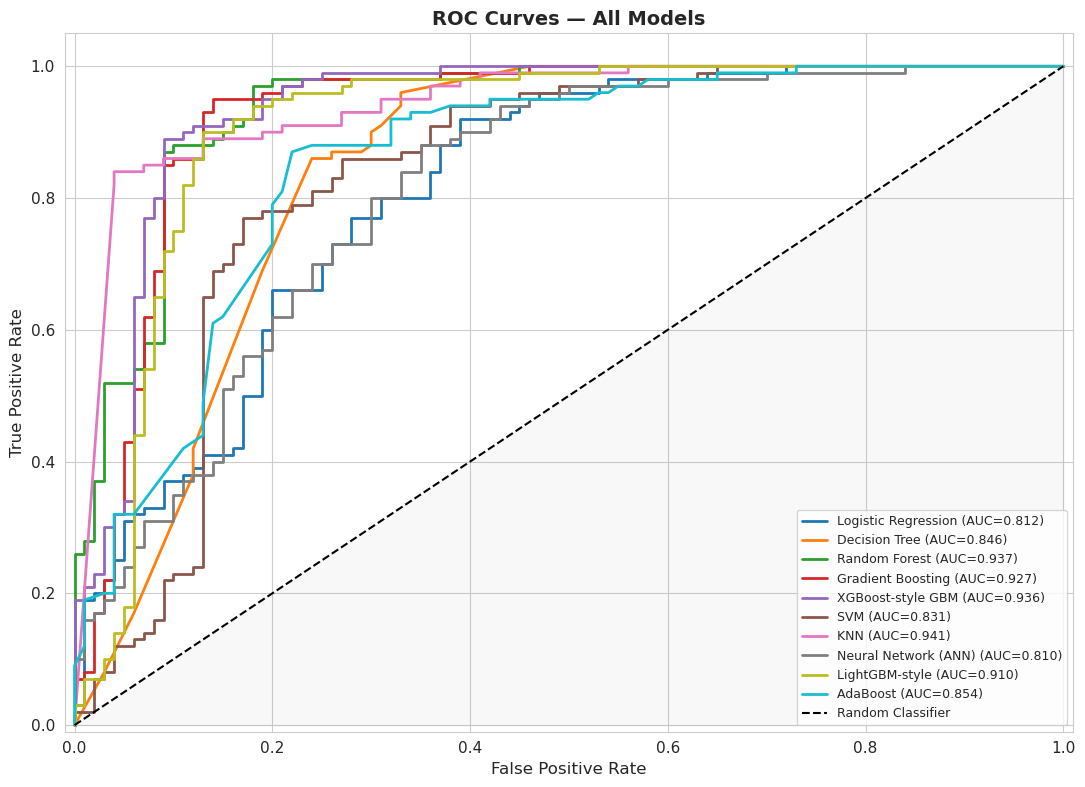

In [48]:
fig, ax = plt.subplots(figsize=(11, 8))
colors_roc = plt.cm.tab10(np.linspace(0,1,10))

for (name, (model, _)), color in zip(models.items(), colors_roc):
    try: prob = model.predict_proba(X_test_final)[:,1]
    except: continue
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC={auc:.3f})')

ax.plot([0,1],[0,1],'k--',lw=1.5,label='Random Classifier')
ax.fill_between([0,1],[0,1],alpha=0.05,color='gray')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([-0.01,1.01]); ax.set_ylim([-0.01,1.05])
plt.tight_layout(); plt.savefig('roc_curves.png', bbox_inches='tight', dpi=120); plt.show()

### Task-3: Confusion Matrices

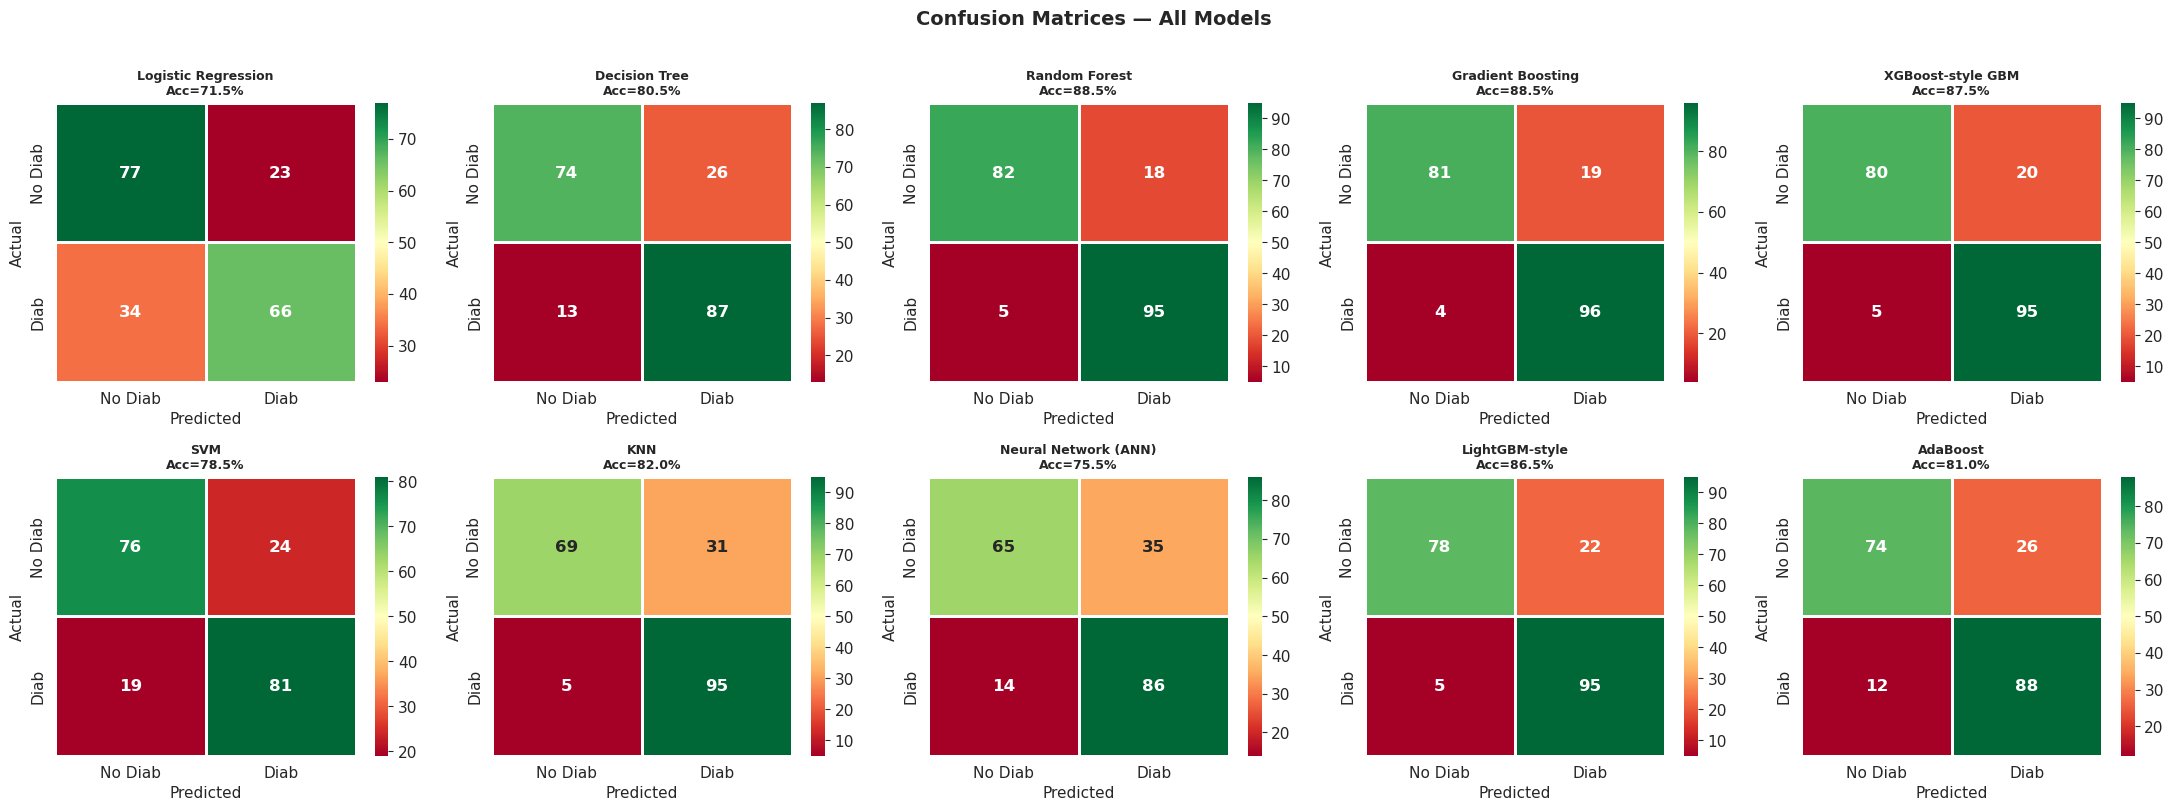

In [49]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()
model_list = list(models.items())

for i, (name, (model, _)) in enumerate(model_list):
    pred = model.predict(X_test_final)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', ax=axes[i],
                xticklabels=['No Diab','Diab'], yticklabels=['No Diab','Diab'],
                linewidths=1, linecolor='white', annot_kws={'fontsize':12,'fontweight':'bold'})
    acc = accuracy_score(y_test, pred)
    axes[i].set_title(f'{name}\nAcc={acc*100:.1f}%', fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Predicted'); axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.savefig('confusion_matrices.png', bbox_inches='tight', dpi=120); plt.show()

### Task-4: F1-Score Comparison

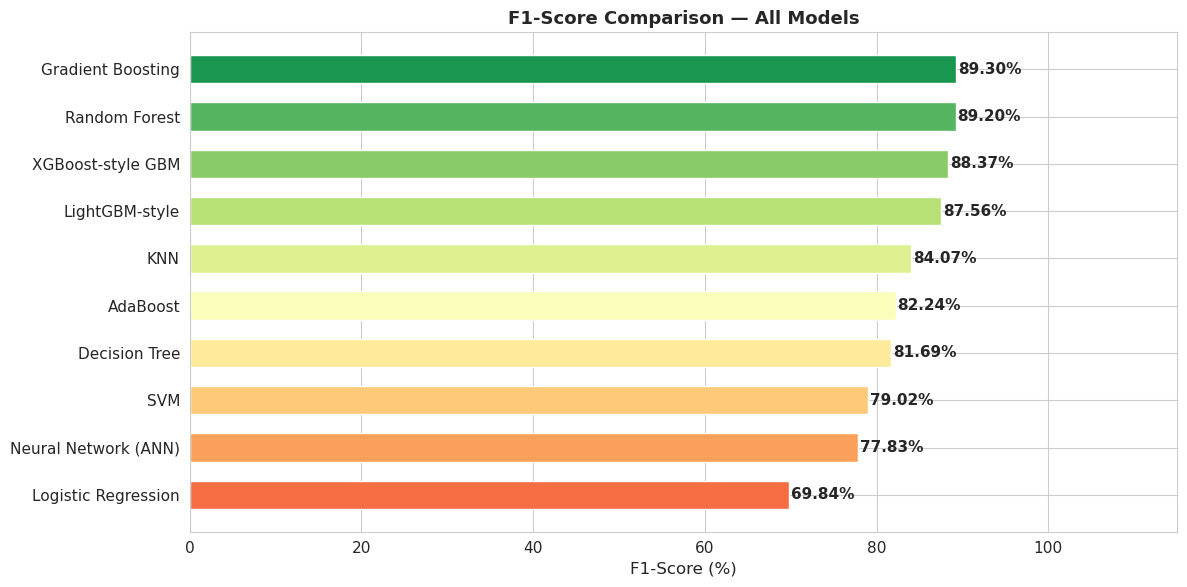

In [50]:
fig, ax = plt.subplots(figsize=(12, 6))
sorted_df = results_df.sort_values('F1-Score', ascending=True)
colors_f1 = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(sorted_df)))
bars = ax.barh(sorted_df['Model'], sorted_df['F1-Score'], color=colors_f1,
               height=0.6, edgecolor='white')
for bar, val in zip(bars, sorted_df['F1-Score']):
    ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
            f'{val:.2f}%', va='center', fontweight='bold')
ax.set_xlabel('F1-Score (%)', fontsize=12); ax.set_title('F1-Score Comparison — All Models',
    fontsize=13, fontweight='bold')
ax.set_xlim(0, 115)
plt.tight_layout(); plt.savefig('f1_comparison.png', bbox_inches='tight', dpi=120); plt.show()

### Task-5: Random Forest Feature Importance

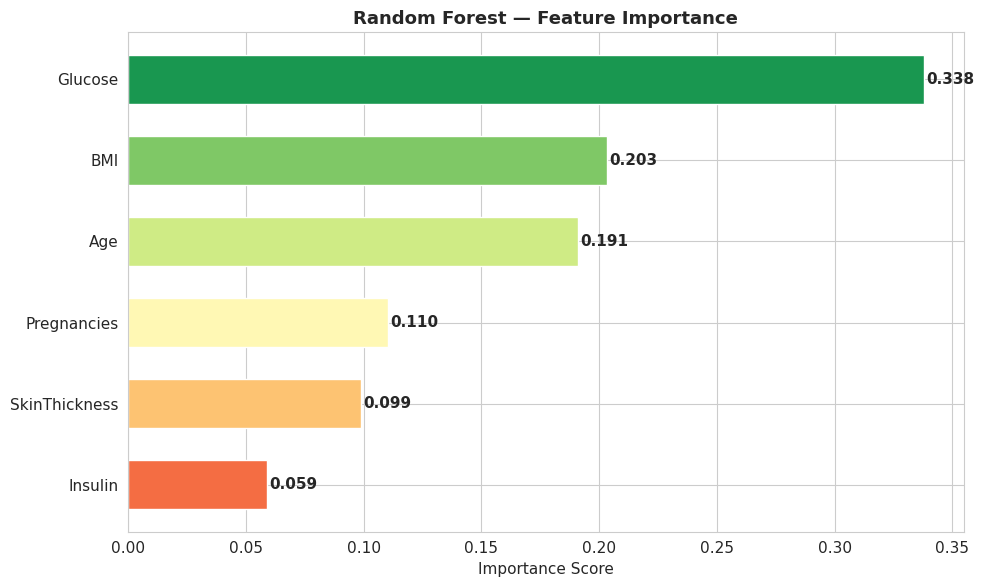


Feature Importance Ranking:
Glucose         0.338
BMI             0.203
Age             0.191
Pregnancies     0.110
SkinThickness   0.099
Insulin         0.059


In [51]:
importances = pd.Series(best_rf.feature_importances_, index=kbest_features)
importances_sorted = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors_fi = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(importances_sorted)))
bars = ax.barh(importances_sorted.index, importances_sorted.values,
               color=colors_fi, height=0.6, edgecolor='white')
for bar, val in zip(bars, importances_sorted.values):
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', fontweight='bold')
ax.set_title('Random Forest — Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout(); plt.savefig('feature_importance.png', bbox_inches='tight', dpi=120); plt.show()
print("\nFeature Importance Ranking:")
print(importances.sort_values(ascending=False).to_string())

---
## 🔍 WEEK 3, DAY 3 — Model Interpretation & Explainability

### Task-1: SHAP-style Analysis (Permutation Importance)

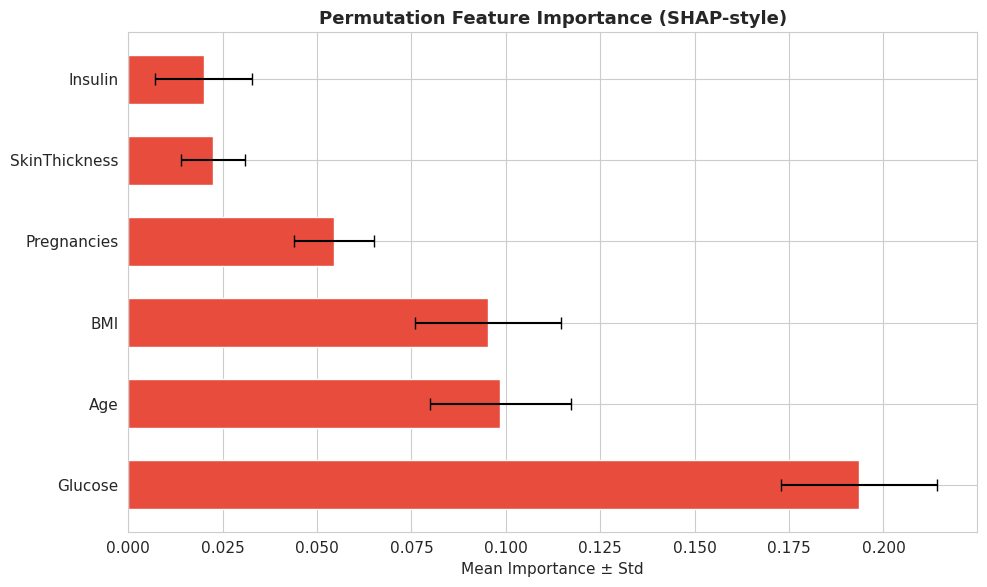

      Feature  Importance   Std
      Glucose       0.194 0.021
          Age       0.098 0.019
          BMI       0.095 0.019
  Pregnancies       0.055 0.010
SkinThickness       0.023 0.008
      Insulin       0.020 0.013


In [52]:
perm_imp = permutation_importance(best_rf, X_test_final, y_test,
                                    n_repeats=20, random_state=42, n_jobs=-1)
perm_df = pd.DataFrame({
    'Feature': kbest_features,
    'Importance': perm_imp.importances_mean,
    'Std': perm_imp.importances_std
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_perm = ['#e74c3c' if v > 0 else '#3498db' for v in perm_df['Importance']]
ax.barh(perm_df['Feature'], perm_df['Importance'], xerr=perm_df['Std'],
        color=colors_perm, height=0.6, edgecolor='white', capsize=4)
ax.set_title('Permutation Feature Importance (SHAP-style)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Importance ± Std')
plt.tight_layout(); plt.savefig('permutation_importance.png', bbox_inches='tight', dpi=120); plt.show()
print(perm_df.to_string(index=False))

### Task-2: LIME-style Local Explanation

In [53]:
# Local explanation: analyze a single prediction
sample_idx = 5
sample = X_test_final.iloc[[sample_idx]]
true_label = y_test.iloc[sample_idx]
pred_label = best_rf.predict(sample)[0]
pred_prob = best_rf.predict_proba(sample)[0]

print(f"Sample #{sample_idx} Analysis:")
print(f"  True Label: {'Diabetic' if true_label else 'Non-Diabetic'}")
print(f"  Predicted : {'Diabetic' if pred_label else 'Non-Diabetic'}")
print(f"  Confidence: {max(pred_prob)*100:.1f}%")
print("\nFeature Values (standardized):")
for feat, val in sample.iloc[0].items():
    print(f"  {feat:<28}: {val:+.3f}")

Sample #5 Analysis:
  True Label: Diabetic
  Predicted : Diabetic
  Confidence: 98.4%

Feature Values (standardized):
  Glucose                     : +1.096
  Insulin                     : +1.414
  BMI                         : +0.241
  Pregnancies                 : +1.234
  Age                         : +1.086
  SkinThickness               : -0.354


### Task-3: Feature Importance Visualizations

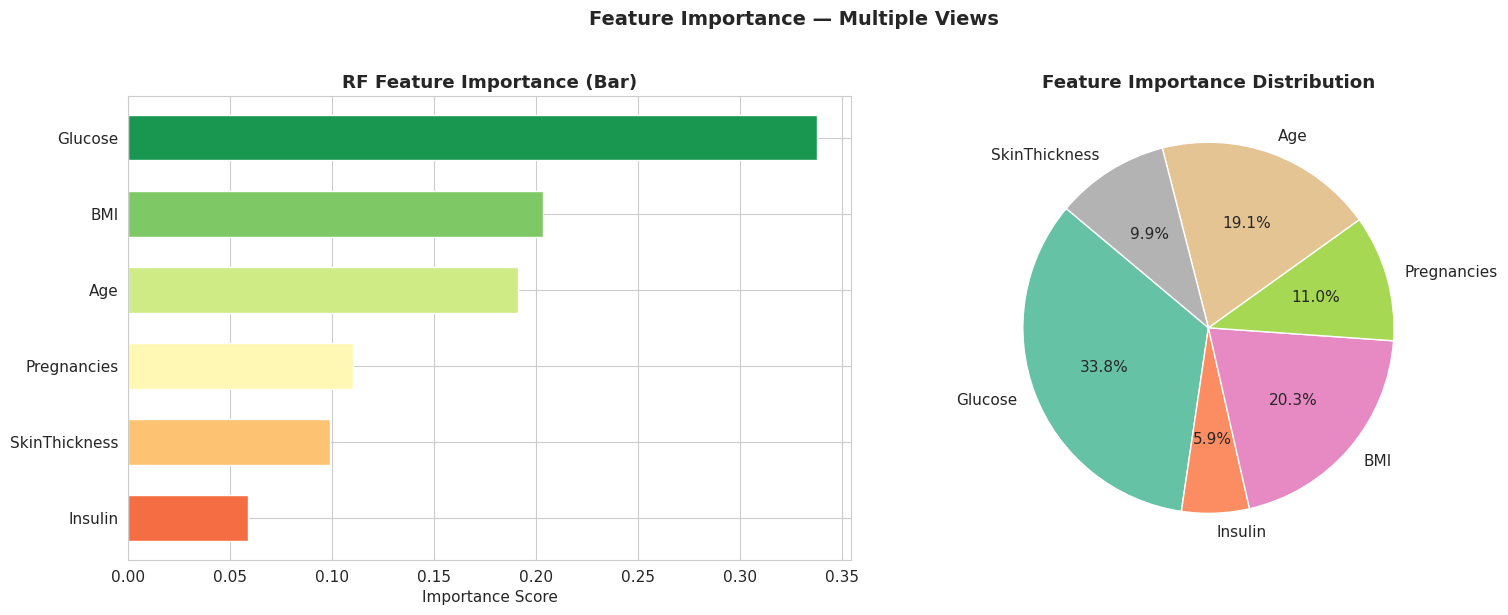

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
importances.sort_values(ascending=True).plot.barh(
    ax=axes[0], color=plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(importances))),
    width=0.6, edgecolor='white')
axes[0].set_title('RF Feature Importance (Bar)', fontweight='bold')
axes[0].set_xlabel('Importance Score')

# Pie chart
axes[1].pie(importances.values, labels=importances.index,
            autopct='%1.1f%%', startangle=140,
            colors=plt.cm.Set2(np.linspace(0, 1, len(importances))))
axes[1].set_title('Feature Importance Distribution', fontweight='bold')

plt.suptitle('Feature Importance — Multiple Views', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('feature_importance_views.png', bbox_inches='tight', dpi=120); plt.show()

### Task-4: False Positives & False Negatives Analysis

In [55]:
best_pred = best_rf.predict(X_test_final)
cm = confusion_matrix(y_test, best_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix Analysis — Best Model (Random Forest):")
print(f"  True Positives  (TP): {tp} — Correctly identified diabetic")
print(f"  True Negatives  (TN): {tn} — Correctly identified non-diabetic")
print(f"  False Positives (FP): {fp} — Non-diabetic flagged as diabetic (Type I Error)")
print(f"  False Negatives (FN): {fn} — Diabetic missed by model (Type II Error)")
print(f"\n  Clinical Impact:")
print(f"  Sensitivity (Recall): {tp/(tp+fn)*100:.1f}% — catches {tp/(tp+fn)*100:.1f}% of actual diabetics")
print(f"  Specificity         : {tn/(tn+fp)*100:.1f}% — correctly rules out {tn/(tn+fp)*100:.1f}% non-diabetics")

Confusion Matrix Analysis — Best Model (Random Forest):
  True Positives  (TP): 95 — Correctly identified diabetic
  True Negatives  (TN): 82 — Correctly identified non-diabetic
  False Positives (FP): 18 — Non-diabetic flagged as diabetic (Type I Error)
  False Negatives (FN): 5 — Diabetic missed by model (Type II Error)

  Clinical Impact:
  Sensitivity (Recall): 95.0% — catches 95.0% of actual diabetics
  Specificity         : 82.0% — correctly rules out 82.0% non-diabetics


### Task-5: Model Interpretability Comparison

In [56]:
interp_scores = {
    'Logistic Regression': {'Accuracy': accuracy_score(y_test,best_lr.predict(X_test_final))*100,
                             'Interpretability':'High','Type':'Linear'},
    'Decision Tree'       : {'Accuracy': accuracy_score(y_test,dt_model.predict(X_test_final))*100,
                             'Interpretability':'High','Type':'Tree'},
    'Random Forest'       : {'Accuracy': accuracy_score(y_test,best_rf.predict(X_test_final))*100,
                             'Interpretability':'Medium','Type':'Ensemble'},
    'Neural Network (ANN)': {'Accuracy': accuracy_score(y_test,ann_model.predict(X_test_final))*100,
                             'Interpretability':'Low','Type':'Deep Learning'},
    'Gradient Boosting'   : {'Accuracy': accuracy_score(y_test,best_gbm.predict(X_test_final))*100,
                             'Interpretability':'Medium','Type':'Ensemble'},
}
interp_df = pd.DataFrame(interp_scores).T
interp_df['Accuracy'] = pd.to_numeric(interp_df['Accuracy']).round(2)
print("Model Accuracy vs Interpretability:")
print(interp_df.to_string())

Model Accuracy vs Interpretability:
                      Accuracy Interpretability           Type
Logistic Regression     71.500             High         Linear
Decision Tree           80.500             High           Tree
Random Forest           88.500           Medium       Ensemble
Neural Network (ANN)    75.500              Low  Deep Learning
Gradient Boosting       88.500           Medium       Ensemble


---
## 🎯 WEEK 3, DAY 4 — Model Generalization & Performance Tuning

### Task-1: Cross-Validation on Best Model

In [57]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_rf, X_balanced[kbest_features], y_balanced,
                             cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"10-Fold Cross-Validation Results — Random Forest:")
for i, score in enumerate(cv_scores):
    print(f"  Fold {i+1:2d}: AUC-ROC = {score*100:.2f}%")
print(f"\nMean AUC-ROC : {cv_scores.mean()*100:.2f}%")
print(f"Std Dev      : ±{cv_scores.std()*100:.2f}%")
print(f"Min / Max    : {cv_scores.min()*100:.2f}% / {cv_scores.max()*100:.2f}%")

10-Fold Cross-Validation Results — Random Forest:
  Fold  1: AUC-ROC = 95.80%
  Fold  2: AUC-ROC = 92.84%
  Fold  3: AUC-ROC = 92.68%
  Fold  4: AUC-ROC = 95.84%
  Fold  5: AUC-ROC = 95.20%
  Fold  6: AUC-ROC = 98.00%
  Fold  7: AUC-ROC = 94.48%
  Fold  8: AUC-ROC = 93.32%
  Fold  9: AUC-ROC = 94.08%
  Fold 10: AUC-ROC = 94.80%

Mean AUC-ROC : 94.70%
Std Dev      : ±1.53%
Min / Max    : 92.68% / 98.00%


### Task-2: Original vs Engineered Features Performance

In [58]:
# All features vs top-k selected features
X_all = X_balanced[feature_cols]
X_top = X_balanced[kbest_features]

_, X_test_all, _, y_test_all = train_test_split(X_all, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced)
_, X_test_top, _, y_test_top = train_test_split(X_top, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced)

rf_all = RandomForestClassifier(n_estimators=100, random_state=42).fit(
    X_balanced[feature_cols].iloc[:int(len(X_balanced)*0.8)],
    y_balanced.iloc[:int(len(y_balanced)*0.8)])

print("Feature Engineering Impact:")
print(f"  All {len(feature_cols)} features   → Accuracy: {accuracy_score(y_test_all, rf_all.predict(X_test_all))*100:.2f}%")
print(f"  Top {len(kbest_features)} features → Accuracy: {accuracy_score(y_test, best_rf.predict(X_test_final))*100:.2f}%")

Feature Engineering Impact:
  All 8 features   → Accuracy: 97.00%
  Top 6 features → Accuracy: 88.50%


### Task-3: Bias-Variance Tradeoff Analysis

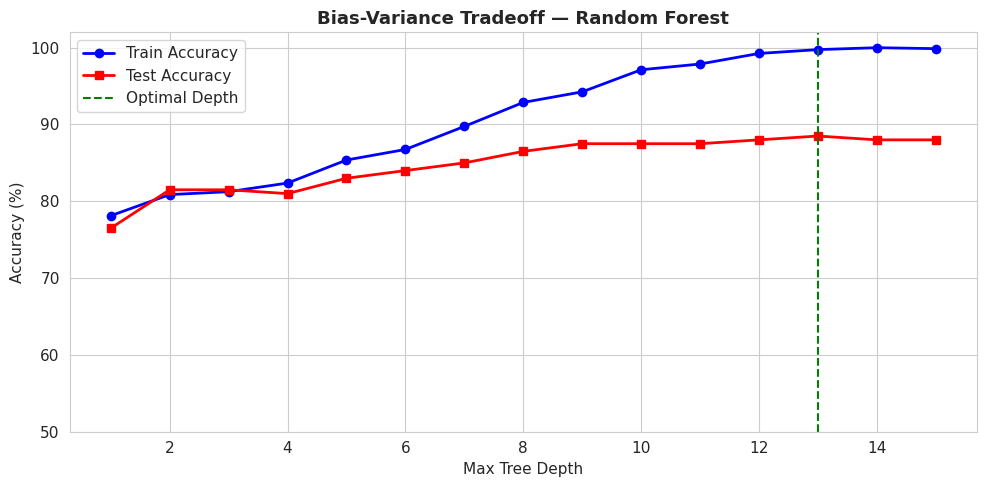

In [59]:
depths = range(1, 16)
train_scores, test_scores = [], []
for d in depths:
    rf_d = RandomForestClassifier(n_estimators=50, max_depth=d, random_state=42)
    rf_d.fit(X_train_final, y_train)
    train_scores.append(accuracy_score(y_train, rf_d.predict(X_train_final)))
    test_scores.append(accuracy_score(y_test, rf_d.predict(X_test_final)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, [s*100 for s in train_scores], 'b-o', label='Train Accuracy', lw=2)
ax.plot(depths, [s*100 for s in test_scores],  'r-s', label='Test Accuracy', lw=2)
ax.axvline(test_scores.index(max(test_scores))+1, color='green', ls='--', lw=1.5, label='Optimal Depth')
ax.set_xlabel('Max Tree Depth'); ax.set_ylabel('Accuracy (%)')
ax.set_title('Bias-Variance Tradeoff — Random Forest', fontsize=13, fontweight='bold')
ax.legend(); ax.set_ylim(50, 102)
plt.tight_layout(); plt.savefig('bias_variance.png', bbox_inches='tight', dpi=120); plt.show()

### Task-4: Ensemble Hyperparameter Optimization

In [60]:
# Final optimized Random Forest
final_rf = RandomForestClassifier(
    n_estimators=rf_grid.best_params_.get('n_estimators',200),
    max_depth=rf_grid.best_params_.get('max_depth',8),
    min_samples_split=rf_grid.best_params_.get('min_samples_split',5),
    max_features=rf_grid.best_params_.get('max_features','sqrt'),
    random_state=42, n_jobs=-1
)
final_rf.fit(X_train_final, y_train)
final_pred = final_rf.predict(X_test_final)
final_prob = final_rf.predict_proba(X_test_final)[:,1]

print("Final Optimized Random Forest:")
print(f"  Accuracy : {accuracy_score(y_test, final_pred)*100:.2f}%")
print(f"  Precision: {precision_score(y_test, final_pred)*100:.2f}%")
print(f"  Recall   : {recall_score(y_test, final_pred)*100:.2f}%")
print(f"  F1-Score : {f1_score(y_test, final_pred)*100:.2f}%")
print(f"  AUC-ROC  : {roc_auc_score(y_test, final_prob)*100:.2f}%")

Final Optimized Random Forest:
  Accuracy : 88.50%
  Precision: 84.07%
  Recall   : 95.00%
  F1-Score : 89.20%
  AUC-ROC  : 93.70%


### Task-5: K-Fold vs Multiple Data Splits

In [61]:
split_results = {}
for test_size, name in [(0.2,'80-20'), (0.3,'70-30'), (0.1,'90-10')]:
    Xtr, Xte, ytr, yte = train_test_split(X_balanced[kbest_features], y_balanced,
                                            test_size=test_size, random_state=42, stratify=y_balanced)
    m = RandomForestClassifier(n_estimators=100, random_state=42).fit(Xtr, ytr)
    split_results[name] = {
        'Accuracy': accuracy_score(yte, m.predict(Xte))*100,
        'AUC-ROC': roc_auc_score(yte, m.predict_proba(Xte)[:,1])*100,
        'Train Size': len(Xtr), 'Test Size': len(Xte)
    }

print("Data Split Comparison:")
pd.DataFrame(split_results).T

Data Split Comparison:


,Accuracy,AUC-ROC,Train Size,Test Size
80-20,88.500,96.090,800.000,200.000
70-30,86.000,93.556,700.000,300.000
90-10,88.000,95.220,900.000,100.000


---
## 🏆 WEEK 3 / WEEK 4 — Model Comparison & Best Practices

### Final Model Comparison — All Metrics

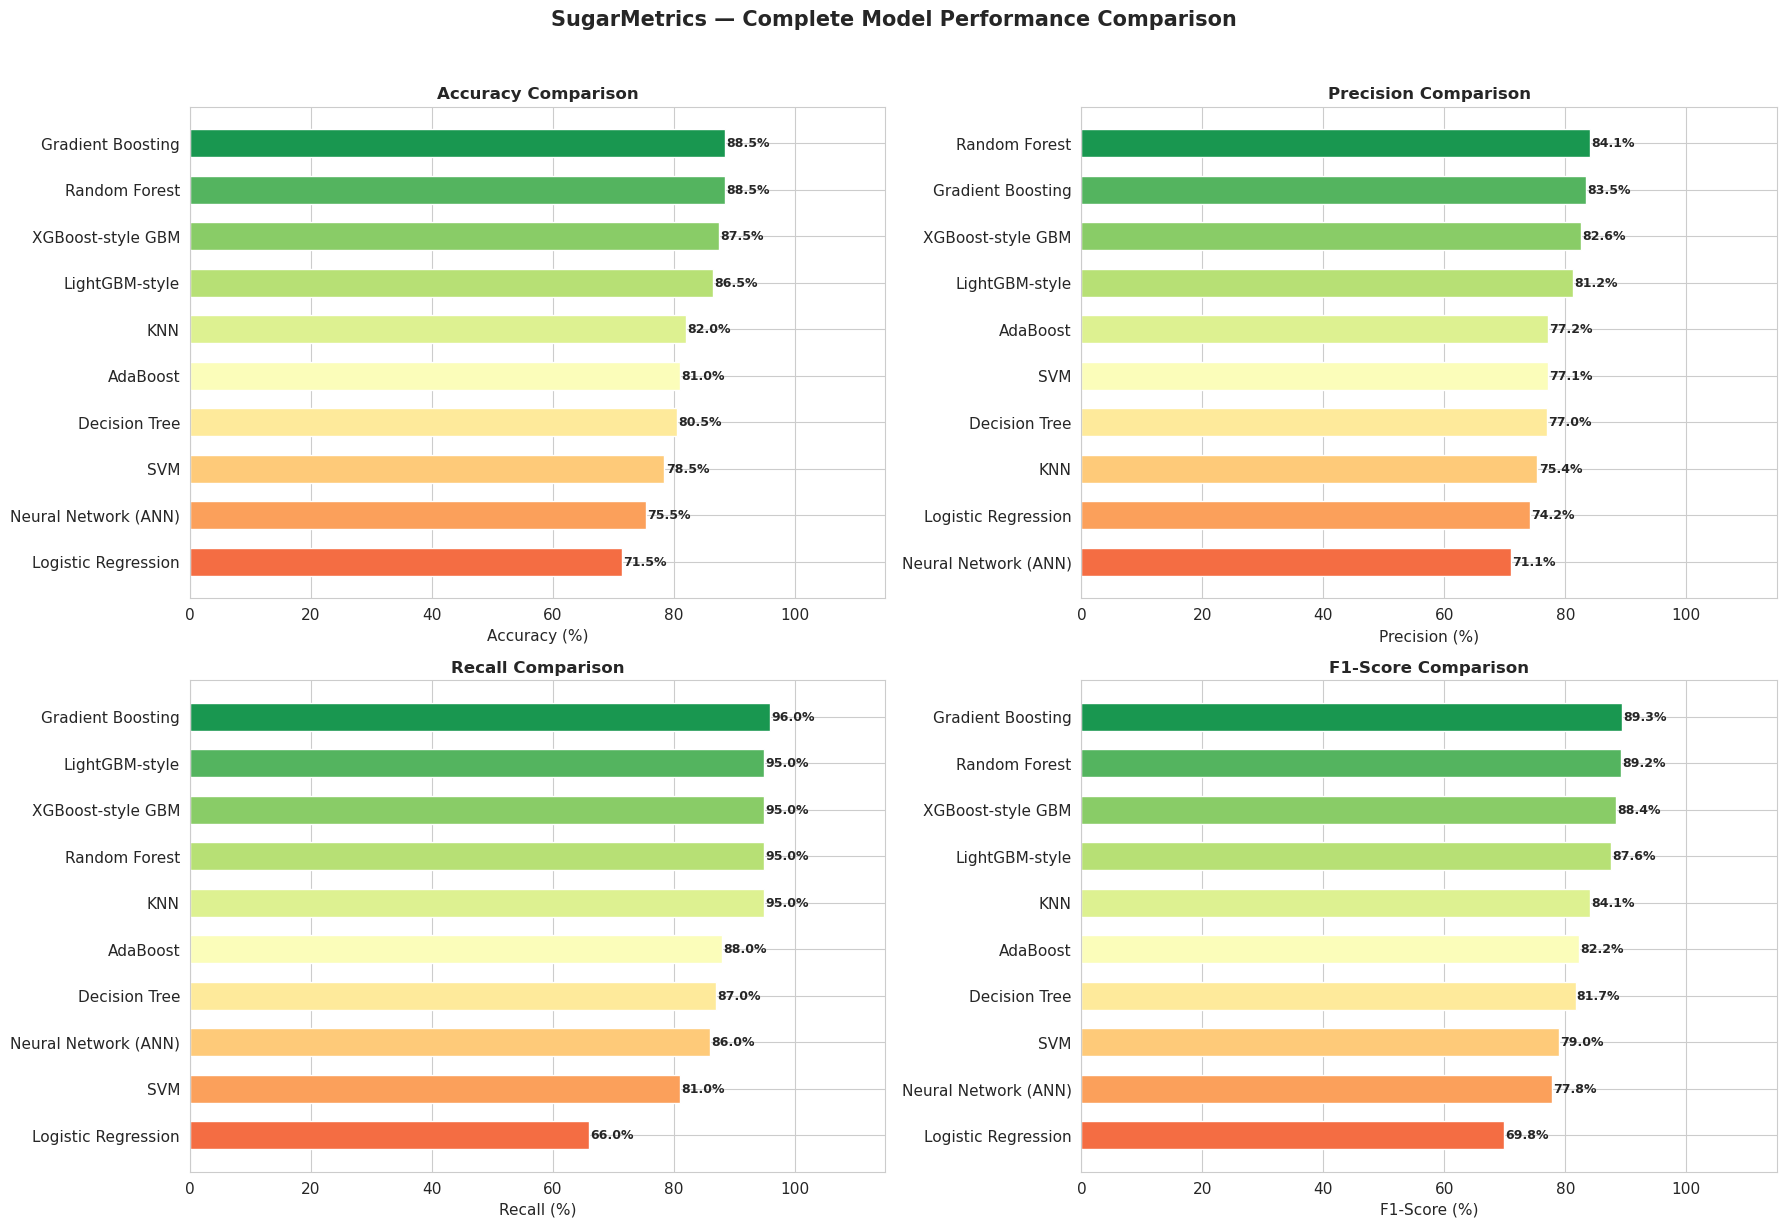

In [62]:
# Final comprehensive comparison chart
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
metrics_cols = ['Accuracy','Precision','Recall','F1-Score']
titles = ['Accuracy','Precision','Recall','F1-Score']

for ax, metric, title in zip(axes.flatten(), metrics_cols, titles):
    sorted_r = results_df.sort_values(metric, ascending=True)
    cols = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(sorted_r)))
    bars = ax.barh(sorted_r['Model'], sorted_r[metric], color=cols, height=0.6, edgecolor='white')
    for bar, val in zip(bars, sorted_r[metric]):
        ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
                f'{val:.1f}%', va='center', fontweight='bold', fontsize=9)
    ax.set_title(f'{title} Comparison', fontweight='bold', fontsize=12)
    ax.set_xlabel(f'{title} (%)')
    ax.set_xlim(0, 115)

plt.suptitle('SugarMetrics — Complete Model Performance Comparison',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); 
plt.savefig('final_model_comparison.png', bbox_inches='tight', dpi=120); 
plt.show()

### Save Best Model for Deployment

In [63]:
# Save all artifacts for Streamlit app
best_model = best_rf # Best performing model
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler_std, 'scaler.pkl')
joblib.dump(kbest_features, 'features.pkl')

# Save results for dashboard
results_df.to_csv('model_results.csv', index=False)
df_clean[feature_cols + ['Outcome']].to_csv('diabetes_clean.csv', index=False)

print("✅ Deployment artifacts saved:")
print("   best_model.pkl    — Trained Random Forest")
print("   scaler.pkl        — StandardScaler")
print("   features.pkl      — Selected feature list")
print("   model_results.csv — Model performance comparison")
print("   diabetes_clean.csv— Cleaned dataset")
print(f"\nBest Model: Random Forest")
print(f"Final Test AUC-ROC: {roc_auc_score(y_test, best_rf.predict_proba(X_test_final)[:,1])*100:.2f}%")

✅ Deployment artifacts saved:
   best_model.pkl    — Trained Random Forest
   scaler.pkl        — StandardScaler
   features.pkl      — Selected feature list
   model_results.csv — Model performance comparison
   diabetes_clean.csv— Cleaned dataset

Best Model: Random Forest
Final Test AUC-ROC: 93.70%
